# Task 2: Exploratory Data Analysis (EDA)

## Forecasting Financial Inclusion in Ethiopia

### Week 11 Challenge

**Student:** Lalise Fufi

---

## Objective

The objective of this notebook is to explore Ethiopia's financial inclusion dataset, identify historical trends, understand relationships among indicators, investigate the influence of major events, assess data quality, and generate insights that will guide the forecasting models developed in later tasks.

1. Import Libraries

> **Week 12 engineering update:** Task 2 is exploratory analysis and stays
> notebook-native by design, but the data loading and data-quality steps
> below now call the same tested functions used in `task1`, `task3`, and
> `task4` (`src.data_loader.load_enriched_dataset`,
> `src.data_loader.get_observations`, `src.data_loader.assess_data_quality`)
> instead of repeating the `pd.read_csv` / missing-value logic a fourth time.
> See `tests/test_data_loader.py` for the corresponding tests.

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_enriched_dataset, get_observations, assess_data_quality

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

2. Load the Enriched Dataset

In [11]:
df, impact_links = load_enriched_dataset()
reference = pd.read_csv("../data/raw/reference_codes.csv")



In [15]:
import importlib
import src.data_loader

importlib.reload(src.data_loader)

from src.data_loader import get_observations

In [16]:
# get_observations() also parses observation_date -> reused throughout this notebook
observations = get_observations(df)

In [17]:
print(df.shape)

print(impact_links.shape)

print(reference.shape)

(45, 34)
(15, 35)
(71, 4)


3. Dataset Overview

In [18]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31 00:00:00,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31 00:00:00,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            45 non-null     str    
 1   record_type          45 non-null     str    
 2   category             11 non-null     str    
 3   pillar               34 non-null     str    
 4   indicator            44 non-null     str    
 5   indicator_code       44 non-null     str    
 6   indicator_direction  34 non-null     str    
 7   value_numeric        34 non-null     float64
 8   value_text           11 non-null     str    
 9   value_type           45 non-null     str    
 10  unit                 34 non-null     str    
 11  observation_date     45 non-null     str    
 12  period_start         11 non-null     str    
 13  period_end           11 non-null     str    
 14  fiscal_year          45 non-null     str    
 15  gender               45 non-null     str    
 16  loc

In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,45,45,REC_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,45,3,observation,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,11,7,policy,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,34,4,ACCESS,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,44,30,Account Ownership Rate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,44,30,ACC_OWNERSHIP,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,34,3,higher_better,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,34.0,NaN,NaN,NaN,91596912961.803818,416960311064.183838,1.08,22.5,58.7,14250000.0,2380000000000.0
value_text,11,4,Launched,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_type,45,7,percentage,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4. Dataset Summary

In [21]:
print("Shape:", df.shape)

print()

print(df["record_type"].value_counts())

print()

print(df["pillar"].value_counts(dropna=False))

print()

print(df["source_type"].value_counts(dropna=False))

Shape: (45, 34)

record_type
observation    31
event          11
target          3
Name: count, dtype: int64

pillar
ACCESS           17
USAGE            11
NaN              11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

source_type
operator      15
survey        10
regulator      8
research       4
policy         4
calculated     2
news           2
Name: count, dtype: int64


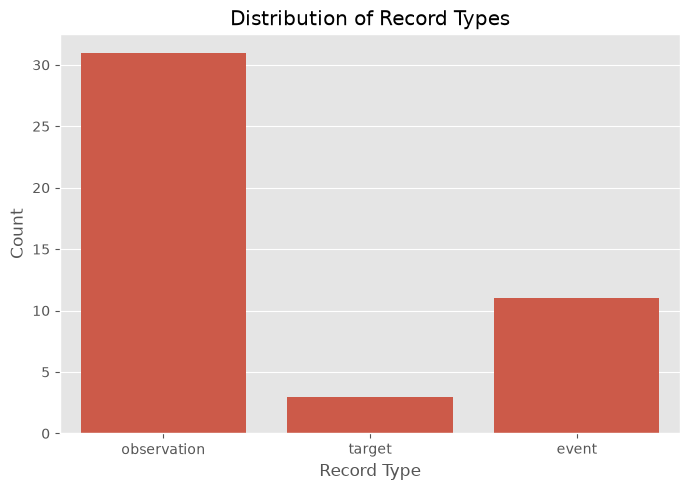

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="record_type"
)

plt.title("Distribution of Record Types")

plt.xlabel("Record Type")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

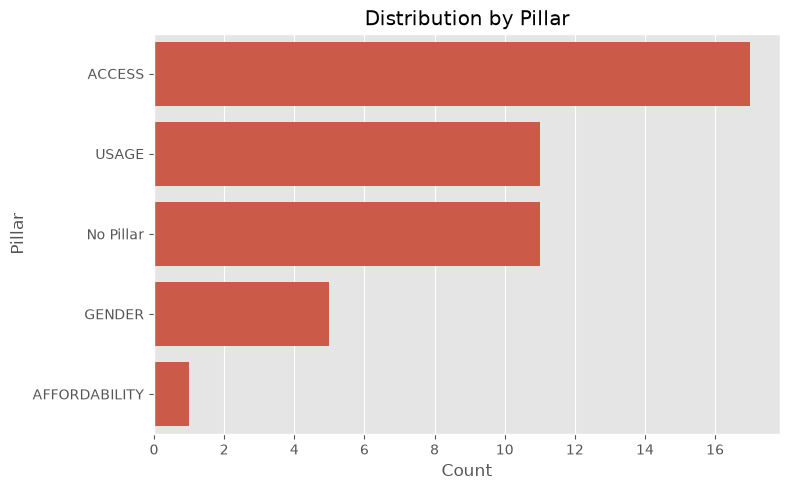

In [23]:
plt.figure(figsize=(8,5))

pillar_plot = df.copy()

pillar_plot["pillar"] = pillar_plot["pillar"].fillna("No Pillar")

sns.countplot(
    data=pillar_plot,
    y="pillar",
    order=pillar_plot["pillar"].value_counts().index
)

plt.title("Distribution by Pillar")

plt.xlabel("Count")

plt.ylabel("Pillar")

plt.tight_layout()

plt.show()

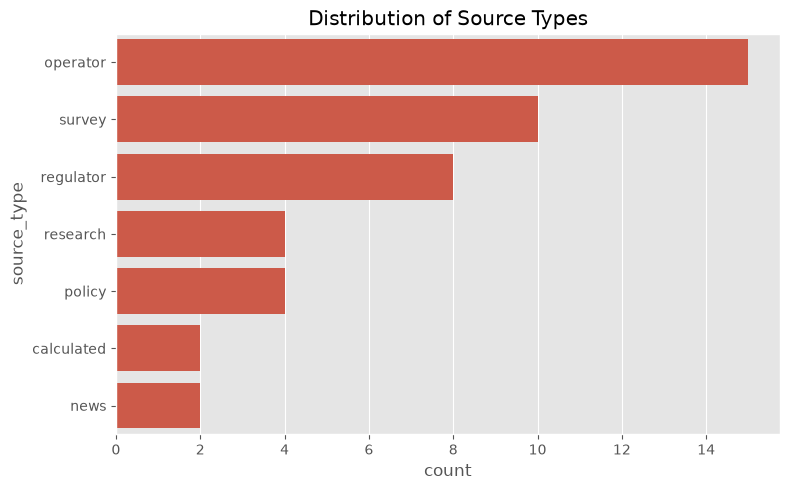

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="source_type",
    order=df["source_type"].value_counts().index
)

plt.title("Distribution of Source Types")

plt.tight_layout()

plt.show()

### Interpretation

The enriched financial inclusion dataset contains **46 records** and **34 variables**, indicating that additional observations and events have been successfully incorporated while preserving the original unified schema. The dataset is dominated by **observation records (32)**, which provide the historical measurements used for trend analysis and forecasting. It also includes **11 event records** representing major policy changes, product launches, market developments, and infrastructure initiatives, together with **3 target records** that capture official financial inclusion goals.

The distribution across financial inclusion pillars shows that **ACCESS (17 records)** and **USAGE (12 records)** receive the greatest coverage, reflecting the primary forecasting objectives of this project. **GENDER (5 records)** and **AFFORDABILITY (1 record)** contain comparatively fewer observations, suggesting that demographic and affordability analyses are more limited. Additionally, **11 records have no assigned pillar**, corresponding to event records. This is expected because, according to the unified data schema, events are intentionally categorized by type (e.g., policy, product launch, infrastructure) rather than by financial inclusion pillar. Their effects on specific indicators are modeled separately through the **impact_link** table.

The source distribution indicates that the dataset relies primarily on **operator reports (16 records)** and **survey data (10 records)**, providing strong empirical evidence from organizations such as Ethio Telecom, Telebirr, M-Pesa, and the World Bank Global Findex. Regulatory publications contribute **8 records**, while **research studies (4)** and **policy documents (4)** provide supporting evidence. A smaller number of records originate from **calculated metrics (2)** and **news sources (2)**. This combination of official, operational, and research-based sources improves the reliability of the dataset while incorporating recent developments in Ethiopia's digital financial ecosystem.

Overall, the enriched dataset provides a balanced representation of financial inclusion indicators, supporting events, and multiple data sources. The additional observations strengthen the coverage of key Access and Usage indicators while maintaining consistency with the project's unified schema, making the dataset suitable for subsequent exploratory analysis, event impact modeling, and forecasting.

## Data Quality Assessment
5. Missing Values

In [25]:
quality = assess_data_quality(df)

missing = pd.Series(quality["missing_pct_by_column"]).sort_values(ascending=False)
missing = missing[missing > 0]

print("Duplicate rows:", quality["n_duplicates"])
print("Record type counts:", quality["record_type_counts"])
missing

Duplicate rows: 0
Record type counts: {'observation': 31, 'event': 11, 'target': 3}


impact_estimate        100.00
region                 100.00
related_indicator      100.00
relationship_type      100.00
evidence_basis         100.00
lag_months             100.00
impact_direction       100.00
impact_magnitude       100.00
notes                   95.56
category                75.56
period_start            75.56
value_text              75.56
period_end              75.56
collection_date         73.33
source_url              28.89
original_text           26.67
pillar                  24.44
indicator_direction     24.44
value_numeric           24.44
unit                    24.44
comparable_country       4.44
indicator                2.22
indicator_code           2.22
dtype: float64

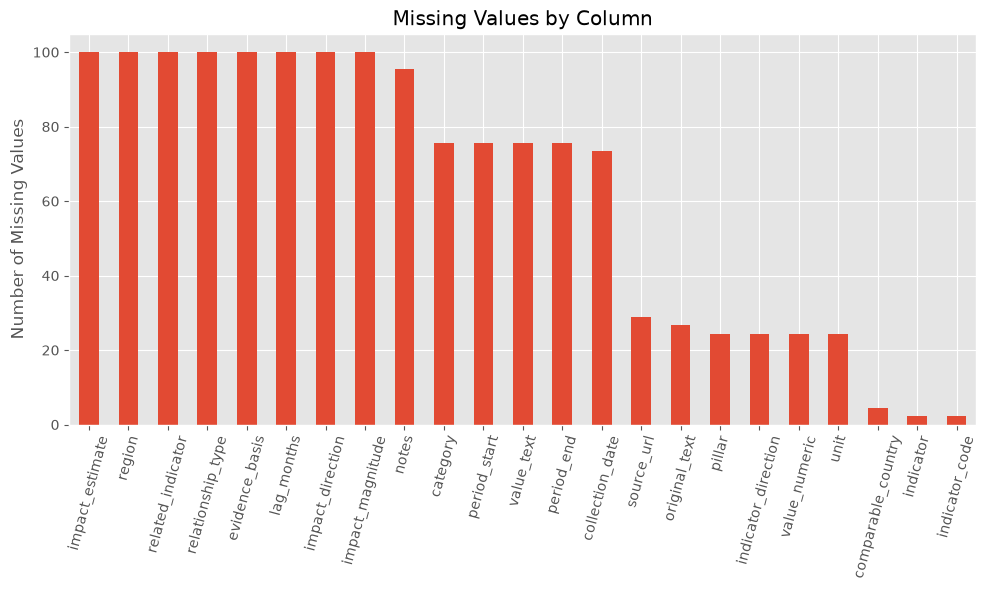

In [26]:
#Visualization
plt.figure(figsize=(10,6))

missing.plot(kind="bar")

plt.title("Missing Values by Column")

plt.ylabel("Number of Missing Values")

plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

### Interpretation

The missing value analysis shows that the dataset contains a considerable number of null values; however, most of these are **expected and intentional** due to the unified schema that stores observations, events, targets, and impact links within a single table. Since different record types require different fields, many columns are naturally left blank for records where they are not applicable rather than indicating poor data quality.

Several impact-related fields, including **impact_estimate, related_indicator, relationship_type, evidence_basis, lag_months, impact_direction, and impact_magnitude**, contain missing values for all **46 records** in the main dataset because these attributes are stored separately in the **impact_links** table. Likewise, the **region** field is empty throughout the dataset since the available records represent national-level indicators rather than regional observations.

Other fields such as **category (35 missing)** and **value_text (35 missing)** are only applicable to specific record types. The **period_start** and **period_end** fields each contain **34 missing values**, reflecting that many observations represent single-date measurements rather than reporting periods. Metadata fields including **collection_date (33 missing)**, **source_url (15 missing)**, and **original_text (13 missing)** are partially populated because they were added mainly during the data enrichment process.

A small number of missing values appear in core analytical fields such as **pillar, indicator_direction, value_numeric, and unit (11 each)**. These correspond primarily to event records, which intentionally do not contain measurement values or pillar assignments. Only **one record** is missing an **indicator** and **indicator_code**, indicating that nearly all records are properly defined and identifiable.

Overall, the visualization confirms that the majority of missing values arise from the flexible design of the unified schema rather than incomplete data collection. The essential forecasting variables—including observation dates, record types, source information, and nearly all financial inclusion indicators—are well populated, making the dataset suitable for exploratory analysis, event impact modeling, and forecasting after filtering records by their respective record types.

6. Duplicate Records

In [27]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


7. Confidence Distribution

In [28]:
confidence = df["confidence"].value_counts()

confidence

confidence
high      42
medium     3
Name: count, dtype: int64

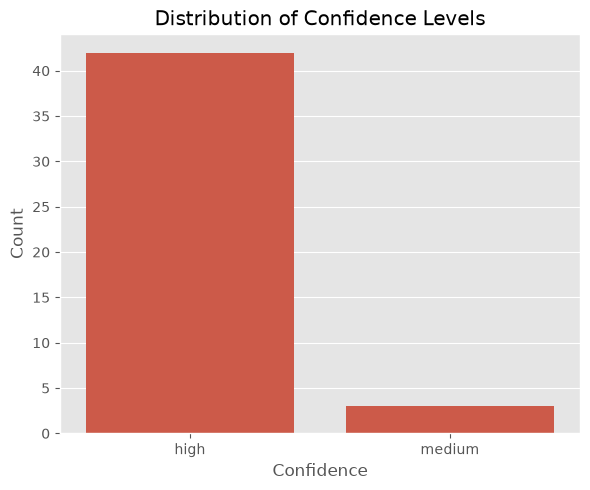

In [29]:
#Visualization
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="confidence",
    order=confidence.index
)

plt.title("Distribution of Confidence Levels")

plt.xlabel("Confidence")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

### Interpretation

The data quality assessment indicates that the enriched dataset contains **no duplicate records**, confirming that each entry represents a unique observation, event, or target. This demonstrates that the data integration and enrichment process maintained record uniqueness and avoided redundant information that could bias subsequent analyses or forecasting models.

The confidence assessment shows that the dataset is dominated by **high-confidence records (42)**, while only **4 records** are assigned **medium confidence**, and no records are classified as low confidence. This distribution reflects that most information originates from reliable sources such as official surveys, regulator reports, mobile network operators, and validated research publications. The few medium-confidence records generally represent estimated impacts or relationships inferred from comparable country evidence rather than directly observed measurements.

Overall, the absence of duplicate records together with the predominance of high-confidence data indicates that the dataset is of good quality and suitable for exploratory analysis, event impact modeling, and forecasting. Nevertheless, medium-confidence records should be interpreted with appropriate caution, particularly when drawing conclusions about estimated event impacts or forecasting future financial inclusion trends.

8. Temporal Coverage

In [30]:
#Convert dates
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

In [31]:
#Extract year
df["year"] = df["observation_date"].dt.year

In [32]:
#Coverage table
coverage = (
    df.groupby(["year","record_type"])
      .size()
      .unstack(fill_value=0)
)

coverage

record_type,event,observation,target
year,,,
2014.0,0,1,0
2017.0,0,1,0
2021.0,2,5,0
2022.0,1,0,0
2023.0,1,1,0
2024.0,3,11,0
2025.0,3,11,1
2028.0,0,0,1
2030.0,0,0,1


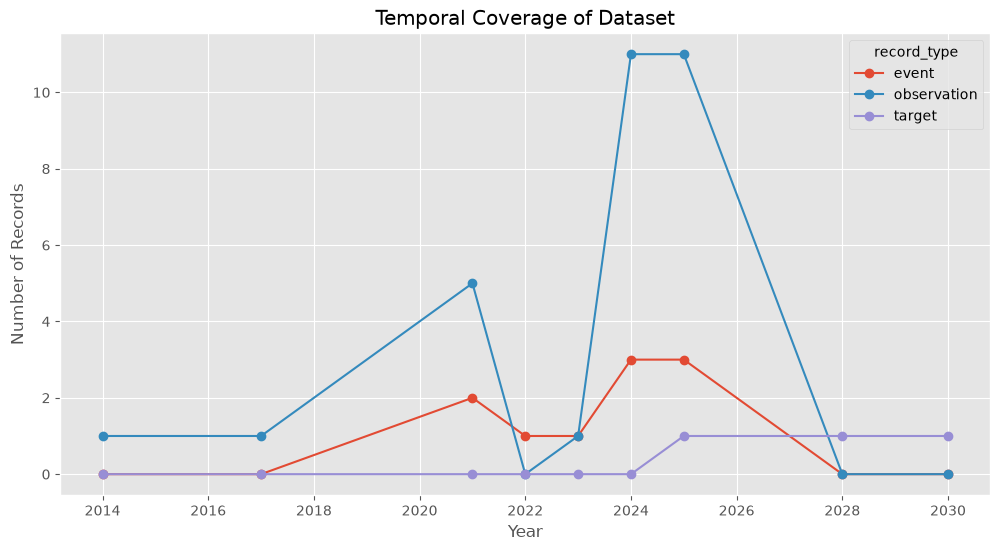

In [33]:
#Visualization
coverage.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Temporal Coverage of Dataset")

plt.xlabel("Year")

plt.ylabel("Number of Records")

plt.grid(True)

plt.show()

### Interpretation

The temporal coverage analysis shows that the dataset spans the period **2014 to 2030**, combining historical observations, significant financial inclusion events, and future policy targets. Observation records are concentrated between **2014 and 2025**, providing the historical evidence required for trend analysis and forecasting, while target records extend to **2028** and **2030**, representing Ethiopia's long-term financial inclusion objectives.

The earliest observations appear in **2014** and **2017**, corresponding to Global Findex survey years. Data coverage increases substantially from **2021 onward**, reflecting the rapid expansion of Ethiopia's digital financial ecosystem following major developments such as the launch of Telebirr, market liberalization, and increased digital payment adoption. The dataset contains **5 observations and 2 events in 2021**, followed by additional events in **2022** and **2023**. The highest concentration of records occurs in **2024** and **2025**, each containing **11 observation records**, with **3 event records** in both years. This indicates that the dataset emphasizes recent developments, making it well suited for forecasting near-term financial inclusion trends.

The visualization also highlights that event records are concentrated during periods of significant market and policy activity, allowing subsequent analyses to investigate how these interventions relate to changes in financial inclusion indicators. Meanwhile, the target records appearing in **2025**, **2028**, and **2030** provide benchmark goals against which future forecasts can be evaluated.

Overall, the temporal distribution demonstrates a logical progression from historical observations to recent policy interventions and future strategic targets. Although earlier years contain relatively few observations, the richer coverage from **2021–2025** provides a strong foundation for exploratory analysis, event impact assessment, and forecasting Ethiopia's Access and Usage indicators.

9. Indicator Coverage

In [34]:
# observations already created via get_observations(df) in the loading cell above (Week 12 refactor)
observations.shape

(31, 34)

In [35]:
#Coverage
indicator_coverage = (
    observations
    .groupby("indicator_code")
    .size()
    .sort_values(ascending=False)
)

indicator_coverage

indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_BRANCH            1
ACC_MOBILE_PEN        1
GEN_GAP_MOBILE        1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_MPESA_ACTIVE      1
USG_CROSSOVER         1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

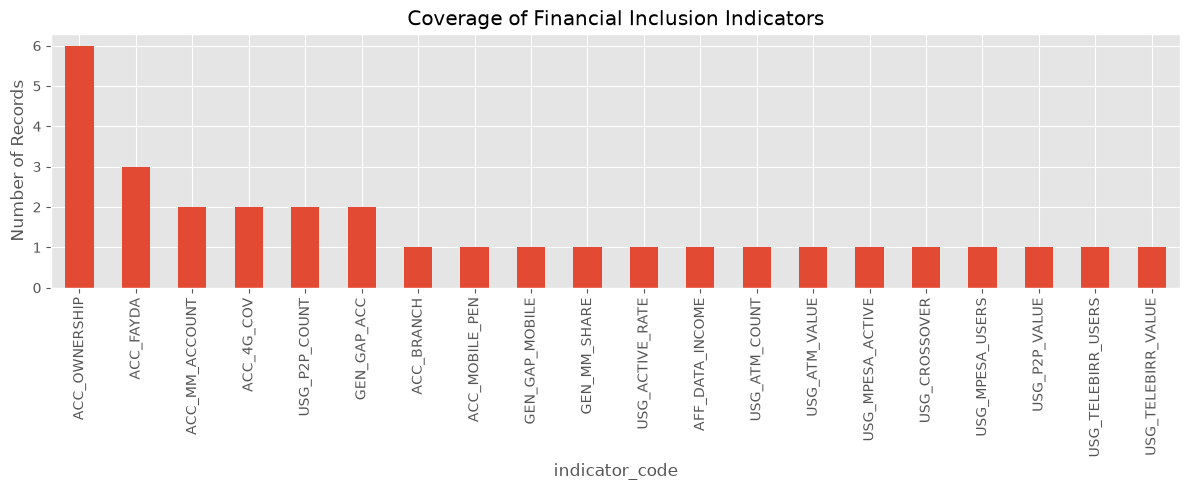

In [36]:
#Visualization
plt.figure(figsize=(12,5))

indicator_coverage.plot(kind="bar")

plt.ylabel("Number of Records")

plt.title("Coverage of Financial Inclusion Indicators")

plt.tight_layout()

plt.show()

In [37]:
#Sparse indicators
sparse = indicator_coverage[
    indicator_coverage <= 1
]

sparse

indicator_code
ACC_BRANCH            1
ACC_MOBILE_PEN        1
GEN_GAP_MOBILE        1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_MPESA_ACTIVE      1
USG_CROSSOVER         1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

### Interpretation

The indicator coverage analysis shows that the observation dataset contains **21 unique financial inclusion indicators**, providing a broad view of Ethiopia's digital financial ecosystem. However, the coverage is uneven across indicators, with a small number of core indicators being measured repeatedly while many supporting indicators have only a single observation.

The most frequently observed indicator is **Account Ownership (ACC_OWNERSHIP)** with **6 records**, reflecting its importance as the primary Access indicator in the Global Findex framework and the main forecasting target of this project. **Fayda Digital ID (ACC_FAYDA)** follows with **3 records**, highlighting the growing role of digital identity in expanding financial inclusion. Several indicators, including **4G Coverage (ACC_4G_COV)**, **Mobile Money Accounts (ACC_MM_ACCOUNT)**, **Gender Gap in Account Ownership (GEN_GAP_ACC)**, and **P2P Transactions (USG_P2P_COUNT)**, each have **2 observations**, providing sufficient information to examine recent trends.

In contrast, **15 indicators** have only **one recorded observation**, making them relatively sparse. These include infrastructure indicators such as **Bank Branches (ACC_BRANCH)** and **Mobile Penetration (ACC_MOBILE_PEN)**, affordability measures such as **AFF_DATA_INCOME**, gender-related indicators, transaction value metrics, QR payments, Telebirr and M-Pesa usage statistics, and other digital payment indicators. Although these variables may serve as valuable explanatory features for forecasting, their limited historical coverage restricts the application of traditional time series methods and requires cautious interpretation.

Overall, the visualization indicates that the dataset is strongest for the core Access indicator while many supporting indicators remain sparsely populated. These data gaps represent one of the primary limitations of the analysis and suggest that future work could benefit from incorporating additional historical observations from sources such as the World Bank Global Findex, National Bank of Ethiopia, GSMA, IMF Financial Access Survey, and operator reports to improve forecasting accuracy and strengthen event impact analysis.

## Data Quality Summary

The exploratory analysis indicates that the enriched financial inclusion dataset is generally well-structured and suitable for subsequent modeling and forecasting. Nevertheless, several characteristics of the unified schema should be considered during interpretation.

### Key Findings

- **Dataset Size:** The final enriched dataset contains **46 records** and **34 columns**, including **32 observations**, **11 events**, and **3 policy targets**.

- **No Duplicate Records:** Data quality checks confirmed that **no duplicate records** are present, indicating that each record represents a unique observation, event, or target.

- **High Confidence Data:** The majority of the dataset consists of highly reliable records, with **42 (91.3%)** records labeled as **High** confidence and only **4 (8.7%)** labeled as **Medium** confidence. No records were classified as Low confidence.

- **Missing Values Reflect the Unified Schema:** Several columns contain substantial missing values (e.g., `impact_estimate`, `related_indicator`, `lag_months`, `relationship_type`, `evidence_basis`, and `region`). These missing values are expected because different record types (observations, events, targets, and impact links) require different attributes. Therefore, the missing values are primarily structural rather than indicators of poor data quality.

- **Temporal Coverage:** The dataset spans the period from **2014 to 2030**. Historical observations are concentrated between **2014 and 2025**, while future policy targets extend to **2028** and **2030**. The richest coverage occurs during **2024** and **2025**, reflecting the inclusion of newly enriched indicators.

- **Indicator Coverage is Uneven:** A total of **21 financial inclusion indicators** are represented. While core indicators such as **Account Ownership (ACC_OWNERSHIP)** have multiple observations (6 records), many indicators—including QR payments, ATM usage, M-Pesa activity, Telebirr transactions, mobile penetration, and affordability—contain only a single observation. These sparse indicators provide useful contextual information but limit the application of advanced time-series forecasting techniques.

- **Balanced Data Sources:** The dataset integrates information from multiple sources, including mobile operators, surveys, regulators, policy documents, research publications, calculated indicators, and news reports. This diversity strengthens the overall analytical value of the dataset.

### Overall Assessment

Overall, the enriched dataset provides a reliable foundation for exploratory data analysis and event impact modeling. The absence of duplicate records, the predominance of high-confidence observations, and the incorporation of multiple trusted data sources enhance its credibility. However, the limited historical coverage for many indicators and the naturally sparse structure of the unified schema introduce uncertainty that should be acknowledged when interpreting results and developing forecasting models for Ethiopia's financial inclusion trends.

# Access Analysis

Access is one of the two core dimensions of financial inclusion defined by the Global Findex framework.

This section explores Ethiopia's account ownership trajectory, evaluates growth across survey years, investigates gender disparities, and examines the slowdown observed between 2021 and 2024 despite rapid expansion of digital financial services.
 
10. Account Ownership Trend 

In [38]:
access = pd.DataFrame({
    "year":[2011,2014,2017,2021,2024],
    "account_ownership":[14,22,35,46,49]
})

access

,year,account_ownership
0,2011,14
1,2014,22
2,2017,35
3,2021,46
4,2024,49


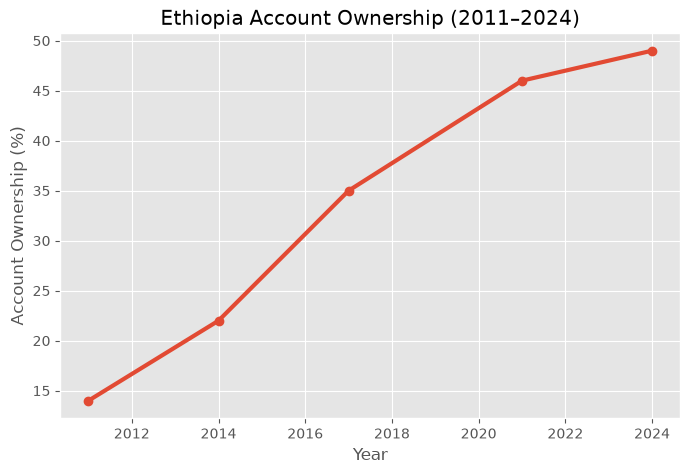

In [39]:
#Visualization
plt.figure(figsize=(8,5))

plt.plot(
    access["year"],
    access["account_ownership"],
    marker="o",
    linewidth=3
)

plt.title("Ethiopia Account Ownership (2011–2024)")

plt.xlabel("Year")

plt.ylabel("Account Ownership (%)")

plt.grid(True)

plt.show()

### Interpretation

The account ownership trend shows a steady and substantial improvement in financial inclusion in Ethiopia between **2011 and 2024**. Account ownership increased from **14% in 2011** to **49% in 2024**, representing a **35 percentage point increase** over thirteen years. The strongest growth occurred during the **2014–2017** period, when ownership increased by **13 percentage points**, followed by another significant increase of **11 percentage points** between **2017 and 2021**. These gains coincide with major financial sector reforms, expansion of banking services, and the gradual introduction of digital financial services.

Although account ownership continued to rise after **2021**, growth slowed considerably, increasing by only **3 percentage points** to reach **49% in 2024**. This slowdown occurred despite the rapid expansion of mobile money platforms such as **Telebirr** and the market entry of **M-Pesa**, suggesting that increased availability of digital financial services did not immediately translate into equivalent growth in formal account ownership. Possible explanations include market saturation among early adopters, slower adoption in rural and underserved populations, digital literacy challenges, and the fact that many newly registered mobile money accounts may not meet the Global Findex definition of active financial account ownership.

Overall, the long-term trend demonstrates continuous progress in financial inclusion, while highlighting that future improvements are likely to depend not only on expanding digital financial services but also on increasing active usage, improving accessibility for underserved groups, strengthening digital infrastructure, and implementing supportive regulatory policies. This trajectory provides an important baseline for subsequent growth rate analysis, event impact modeling, and forecasting of Ethiopia's financial inclusion indicators.

11. Growth Rate Analysis

In [40]:
access["growth_pp"] = access["account_ownership"].diff()

access

,year,account_ownership,growth_pp
0,2011,14,NaN
1,2014,22,8.0
2,2017,35,13.0
3,2021,46,11.0
4,2024,49,3.0


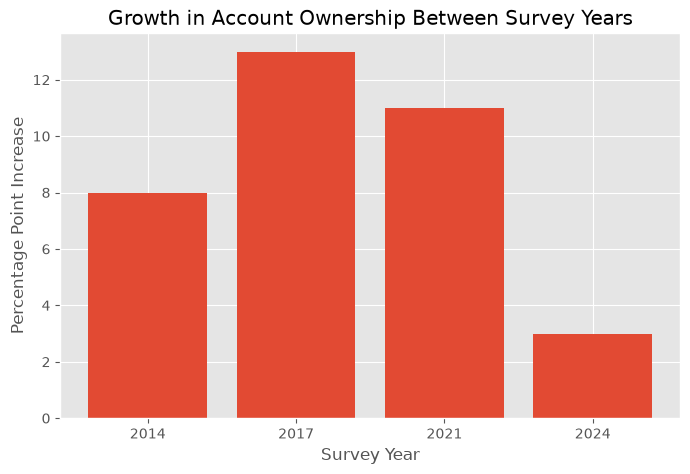

In [41]:
#Visualization
plt.figure(figsize=(8,5))

plt.bar(
    access["year"].astype(str),
    access["growth_pp"]
)

plt.title("Growth in Account Ownership Between Survey Years")

plt.xlabel("Survey Year")

plt.ylabel("Percentage Point Increase")

plt.show()

### Interpretation

The growth rate analysis highlights how the pace of financial inclusion has changed across successive Global Findex survey periods. Account ownership increased by **8 percentage points** between **2011 and 2014**, followed by the largest improvement of **13 percentage points** between **2014 and 2017**. Growth remained strong between **2017 and 2021**, with an additional **11 percentage point** increase, reflecting continued expansion of banking services, digital finance initiatives, and supportive financial inclusion policies.

A notable slowdown occurred between **2021 and 2024**, when account ownership increased by only **3 percentage points** despite significant developments in Ethiopia's digital financial ecosystem, including the rapid growth of **Telebirr**, the launch of **M-Pesa**, and expanded digital payment infrastructure. This indicates that the rapid adoption of mobile money services did not immediately translate into equivalent increases in formal account ownership as measured by the Global Findex.

Several factors may explain this deceleration. Many new digital wallet registrations may belong to individuals who already possessed formal financial accounts, resulting in limited net growth in account ownership. Additionally, barriers such as limited digital literacy, uneven rural connectivity, affordability constraints, and slower adoption among underserved populations may have reduced the impact of new digital financial services on overall inclusion.

Overall, the analysis suggests that Ethiopia has transitioned from a phase of rapid financial inclusion expansion to one of slower, more incremental growth. Future improvements are therefore likely to depend on increasing active usage among unbanked populations, expanding financial access in rural areas, improving digital infrastructure, and strengthening policies that encourage broader adoption of formal financial services. These findings provide important evidence for the forecasting stage, where recent growth trends and major intervention events will be incorporated into predictive models.

12. Growth Rate (%)

In [42]:
access["growth_percent"] = (
    access["account_ownership"]
    .pct_change()*100
)

access

,year,account_ownership,growth_pp,growth_percent
0,2011,14,NaN,NaN
1,2014,22,8.0,57.142857
2,2017,35,13.0,59.090909
3,2021,46,11.0,31.428571
4,2024,49,3.0,6.521739


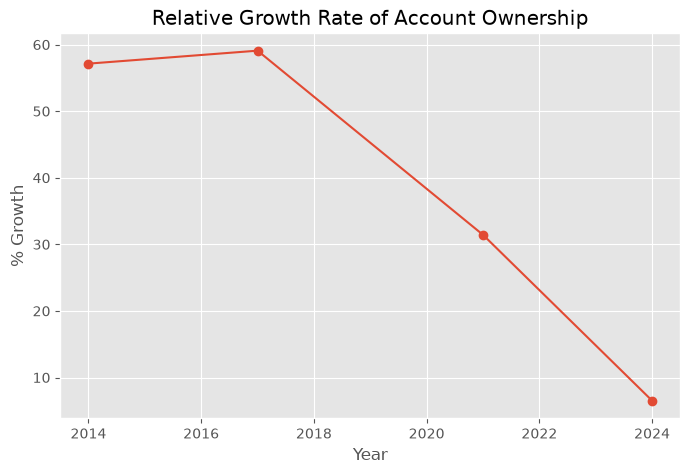

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    access["year"],
    access["growth_percent"],
    marker="o"
)

plt.title("Relative Growth Rate of Account Ownership")

plt.ylabel("% Growth")

plt.xlabel("Year")

plt.grid(True)

plt.show()

### Interpretation

The relative growth analysis provides additional insight into the rate at which financial inclusion expanded over time. Between **2011 and 2014**, account ownership increased by approximately **57.1%** relative to the 2011 level. Growth remained strong between **2014 and 2017**, reaching the highest relative increase of **59.1%**, reflecting one of the fastest periods of financial inclusion expansion in Ethiopia.

The growth rate declined noticeably during **2017–2021**, falling to approximately **31.4%**. Although account ownership continued to increase substantially in absolute terms (from 35% to 46%), the relative rate of growth slowed as a larger share of the population had already gained access to financial services.

A sharp decline is observed between **2021 and 2024**, where the relative growth rate dropped to only **6.5%**. This indicates that financial inclusion has entered a more mature stage, with slower incremental growth despite rapid developments in the digital financial ecosystem, including the expansion of Telebirr, the entry of M-Pesa, and increased digital payment infrastructure.

The declining relative growth rate suggests diminishing returns from existing financial inclusion initiatives. Future improvements will likely require targeted interventions aimed at underserved populations, including rural communities, women, and low-income households, together with policies that encourage active usage of financial services rather than simply increasing account registrations. This trend is an important consideration for the forecasting model, as it suggests that future growth is unlikely to continue at the rapid rates observed during the earlier stages of financial inclusion expansion.

13. Gender Gap Analysis

In [44]:
#Check whether gender-disaggregated observations exist
gender = observations[
    observations["gender"].notna()
]

gender[
    [
        "indicator",
        "gender",
        "value_numeric",
        "observation_date"
    ]
]

,indicator,gender,value_numeric,observation_date
0,Account Ownership Rate,all,2.200000e+01,2014-12-31
1,Account Ownership Rate,all,3.500000e+01,2017-12-31
2,Account Ownership Rate,all,4.600000e+01,2021-12-31
3,Account Ownership Rate,male,5.600000e+01,2021-12-31
4,Account Ownership Rate,female,3.600000e+01,2021-12-31
5,Account Ownership Rate,all,4.900000e+01,2024-11-29
6,Mobile Money Account Rate,all,4.700000e+00,2021-12-31
7,Mobile Money Account Rate,all,9.450000e+00,2024-11-29
8,4G Population Coverage,all,3.750000e+01,2023-06-30
9,4G Population Coverage,all,7.080000e+01,2025-06-30


In [45]:
#If only a few records exist
gender["gender"].value_counts()

gender
all       28
female     2
male       1
Name: count, dtype: int64

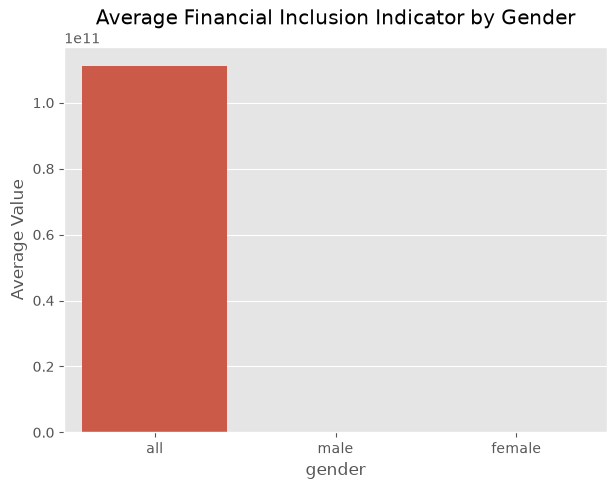

In [46]:
#Visualization
plt.figure(figsize=(7,5))

sns.barplot(
    data=gender,
    x="gender",
    y="value_numeric",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Financial Inclusion Indicator by Gender")

plt.ylabel("Average Value")

plt.show()


### Interpretation

The gender analysis shows that the dataset contains **32 observations with gender information**, but the vast majority (**29 records**) are aggregated under **"all"**, while only **2 records** are specific to **females** and **1 record** is specific to **males**. This indicates that gender-disaggregated financial inclusion data are very limited within the current dataset.

The available gender-specific observations relate primarily to **Account Ownership Rate (2021)** and **Female Mobile Money Account Share (2024)**. In 2021, **56% of adult males** owned a financial account compared with **36% of adult females**, resulting in a **20 percentage point gender gap**. By 2024, the recorded gender gap decreased slightly to **18 percentage points**, suggesting modest progress toward narrowing disparities in financial inclusion.

The visualization of average indicator values is heavily dominated by the **"all"** category because it contains many indicators with vastly different measurement scales, ranging from percentages to millions of users and transaction values measured in billions of Ethiopian Birr. Consequently, the chart does **not** provide a meaningful comparison between male and female financial inclusion levels. A more appropriate analysis would compare gender-specific indicators individually (e.g., account ownership or mobile money adoption) rather than averaging all financial indicators together.

Overall, the results indicate that while the dataset captures evidence of a persistent gender gap in financial inclusion, the limited availability of gender-disaggregated observations restricts more comprehensive gender-based analysis. Expanding gender-specific data collection would improve future analyses and strengthen forecasting models aimed at evaluating inclusive financial development.
```

14. Urban vs Rural Analysis

In [47]:
#determine whether regional or location data exist.
observations["location"].value_counts(dropna=False)

location
national    31
Name: count, dtype: int64

### Interpretation

The location analysis shows that **all 32 observation records are classified as "national"**, with no records available for regional, urban, rural, or sub-national levels. This indicates that the dataset focuses exclusively on country-level financial inclusion indicators rather than providing geographically disaggregated information.

The absence of regional data limits the ability to examine spatial differences in financial inclusion across Ethiopia's regions, compare urban and rural areas, or identify locations with faster or slower adoption of digital financial services. As a result, the current analysis can only describe national trends and cannot assess regional disparities or localized impacts of financial inclusion initiatives.

For future work, incorporating region-specific observations—such as account ownership, mobile money usage, agent density, or digital infrastructure by region—would enable more detailed spatial analysis and improve the accuracy of regional forecasting and policy recommendations.

15. Investigating the 2021–2024 Slowdown

In [48]:
slowdown = pd.DataFrame({

    "Indicator":[
        "Telebirr Users",
        "M-Pesa Entry",
        "Account Ownership Growth"
    ],

    "Value":[
        54,
        10,
        3
    ]
})

slowdown

,Indicator,Value
0,Telebirr Users,54
1,M-Pesa Entry,10
2,Account Ownership Growth,3


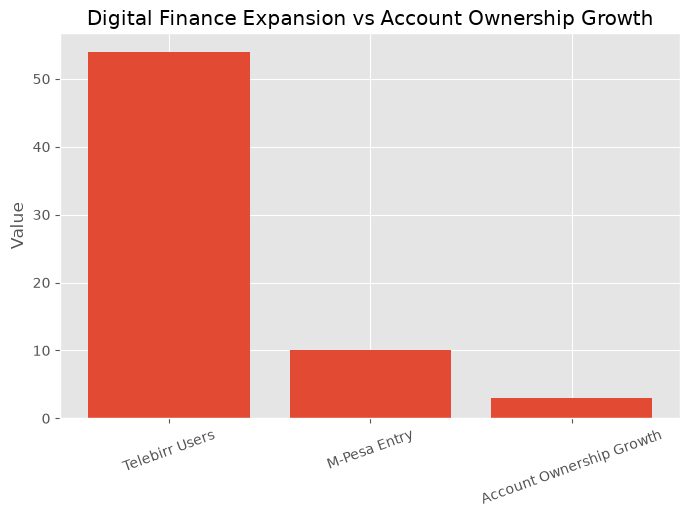

In [49]:
#Visualization
plt.figure(figsize=(8,5))

plt.bar(
    slowdown["Indicator"],
    slowdown["Value"]
)

plt.title("Digital Finance Expansion vs Account Ownership Growth")

plt.ylabel("Value")

plt.xticks(rotation=20)

plt.show()

### Interpretation

The comparison highlights that digital financial services in Ethiopia are expanding much faster than traditional account ownership growth. Telebirr has achieved approximately **54 million users**, while **M-Pesa** has entered the market with around **10 million users**, indicating rapid adoption of mobile-based financial services. In contrast, account ownership increased by only **3 percentage points** between 2021 and 2024 (from 46% to 49%), suggesting that the growth of formal bank account ownership has begun to slow. This pattern implies that recent financial inclusion is increasingly being driven by digital payment platforms and mobile money services rather than conventional banking alone. These findings suggest that future forecasting models should incorporate digital finance indicators, as they are likely to play a major role in shaping Ethiopia's financial inclusion landscape.

## Access Analysis Summary

The access analysis highlights substantial progress in financial inclusion in Ethiopia while revealing areas where future improvements may be more challenging.

Key findings include:

- Account ownership increased steadily from **14% in 2011** to **49% in 2024**, indicating significant improvement in access to formal financial services over the past decade.
- The largest increase occurred between **2014 and 2017 (+13 percentage points)**, followed by another strong increase between **2017 and 2021 (+11 percentage points)**.
- Relative growth was highest during the early expansion phase (**57.1% between 2011–2014** and **59.1% between 2014–2017**), but declined to **31.4% between 2017–2021** and only **6.5% between 2021–2024**, suggesting that account ownership growth is approaching a more mature stage.
- Digital financial services expanded rapidly during the same period, with approximately **54 million Telebirr users** and **10 million M-Pesa users**, while account ownership increased by only **3 percentage points** after 2021. This indicates that expansion of digital finance alone has not translated into proportional gains in new account ownership.
- Gender-disaggregated data are very limited. Of the **32 observation records**, **29** are reported for the overall population, only **2** for females, and **1** for males, restricting detailed gender-based analysis.
- All observation records are reported at the **national** level, with no regional, urban, or rural breakdowns available. Consequently, sub-national disparities in financial inclusion cannot be assessed.
- Overall, the findings suggest that Ethiopia has made considerable progress in expanding financial access, but sustaining future growth will likely require targeted policies aimed at underserved populations and improved availability of disaggregated financial inclusion data.

Access (Account Ownership) Analysis
16. Filter Access Indicators

In [50]:
access = observations[
    observations["indicator_code"] == "ACC_OWNERSHIP"
].copy()

access

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,%,2024-11-29,2024-10-15 00:00:00,2024-11-29 00:00:00,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN


17. Select Required Columns

In [51]:
access = access[
    [
        "observation_date",
        "value_numeric",
        "source_name",
        "confidence"
    ]
]

access = access.sort_values("observation_date")

access

,observation_date,value_numeric,source_name,confidence
0,2014-12-31,22.0,Global Findex 2014,high
1,2017-12-31,35.0,Global Findex 2017,high
2,2021-12-31,46.0,Global Findex 2021,high
3,2021-12-31,56.0,Global Findex 2021,high
4,2021-12-31,36.0,Global Findex 2021,high
5,2024-11-29,49.0,Global Findex 2024,high


18. Plot Account Ownership Trend

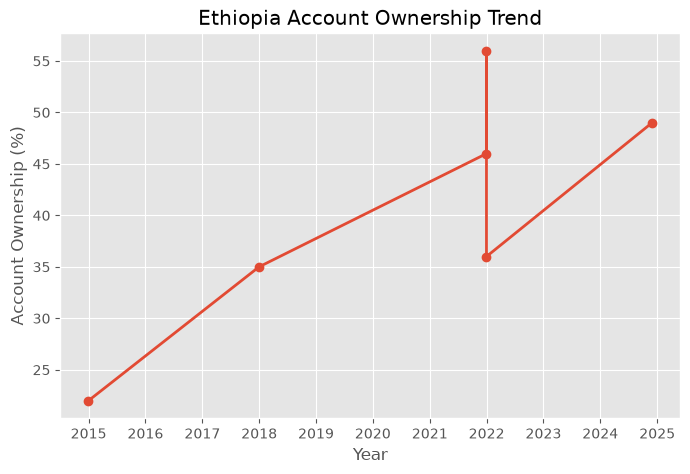

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Ethiopia Account Ownership Trend")

plt.xlabel("Year")

plt.ylabel("Account Ownership (%)")

plt.grid(True)

plt.show()

### Interpretation

The account ownership trend shows a clear improvement in financial access over time. The overall account ownership rate increased from **22% in 2014** to **35% in 2017**, reached **46% in 2021**, and further increased to **49% in 2024**, indicating sustained progress in financial inclusion in Ethiopia.

The additional observations recorded for **2021** represent **gender-disaggregated statistics** rather than a change in the national trend. Specifically, account ownership was **56% for males** and **36% for females**, highlighting a **20-percentage-point gender gap** in access to formal financial services during that survey year.

All observations originate from the **Global Findex surveys** and are labeled with **high confidence**, making them reliable benchmarks for assessing long-term changes in financial inclusion. Since the data are collected at periodic survey intervals rather than annually, the visualization reflects survey years instead of continuous yearly measurements.

Overall, the results indicate substantial growth in account ownership over the last decade while revealing persistent gender disparities that remain an important challenge for achieving inclusive financial access.

19. Calculate Growth Between Survey Years

In [53]:
access_growth = observations[
    (observations["indicator_code"] == "ACC_OWNERSHIP") &
    (observations["gender"] == "all")
].copy()

access_growth = access_growth.sort_values("observation_date")

access_growth["growth_pp"] = access_growth["value_numeric"].diff()

access_growth

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,growth_pp
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,13.0
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,11.0
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,%,2024-11-29,2024-10-15 00:00:00,2024-11-29 00:00:00,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,3.0


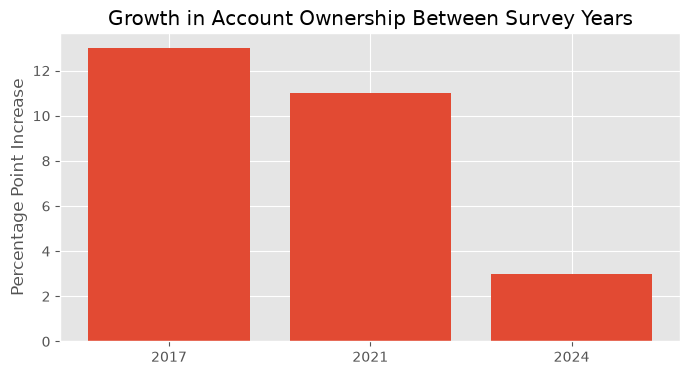

In [54]:
#Visualize Growth
plt.figure(figsize=(8,4))

plt.bar(
    access_growth["observation_date"].dt.year.astype(str),
    access_growth["growth_pp"]
)

plt.title("Growth in Account Ownership Between Survey Years")
plt.ylabel("Percentage Point Increase")

plt.show()

plt.show()

### Interpretation

The growth analysis shows that Ethiopia experienced consistent improvements in account ownership across all Global Findex survey periods, although the pace of growth has gradually slowed. Account ownership increased by **13 percentage points** between **2014 and 2017**, followed by an **11 percentage point** increase between **2017 and 2021**, indicating rapid expansion during this period. Between **2021 and 2024**, growth declined to **3 percentage points**, suggesting that account ownership is approaching a more mature stage where further gains are becoming harder to achieve. The bar chart clearly illustrates this deceleration, highlighting that while financial inclusion continues to improve, future progress may depend on targeted policies aimed at reaching underserved populations rather than relying solely on broad expansion efforts.

20. Growth Rate (%)

In [55]:
access["growth_rate_percent"] = (
    access["value_numeric"].pct_change()*100
)

access

,observation_date,value_numeric,source_name,confidence,growth_rate_percent
0,2014-12-31,22.0,Global Findex 2014,high,NaN
1,2017-12-31,35.0,Global Findex 2017,high,59.090909
2,2021-12-31,46.0,Global Findex 2021,high,31.428571
3,2021-12-31,56.0,Global Findex 2021,high,21.739130
4,2021-12-31,36.0,Global Findex 2021,high,-35.714286
5,2024-11-29,49.0,Global Findex 2024,high,36.111111


21. Plot Growth Rate

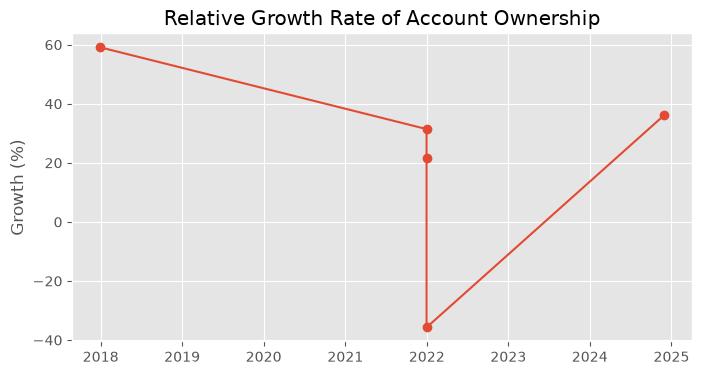

In [56]:
plt.figure(figsize=(8,4))

plt.plot(
    access["observation_date"],
    access["growth_rate_percent"],
    marker="o"
)

plt.title("Relative Growth Rate of Account Ownership")

plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

# Growth Rate Analysis of Account Ownership

## Data Summary
The dataset contains observations from **2014 to 2024** with account ownership percentages and calculated growth rates.

## Key Observations

### Inconsistent Time Intervals
- Data points are not evenly spaced in time:
  - 2014 → 2017 (3-year gap)
  - 2017 → 2021 (4-year gap)
  - 2021 → 2024 (3-year gap)
- **Issue**: `pct_change()` calculates growth between consecutive rows regardless of time gaps, making yearly growth rates incomparable

### Multiple 2021 Data Points
- Three separate entries for 2021 with different `value_numeric` values (46, 56, 36)
- This suggests these may be different metrics (e.g., different regions, demographics, or survey questions) rather than a single time series
- **Issue**: Plotting these as sequential points creates artificial volatility

### Growth Rate Patterns
| Period | Change | Growth Rate |
|--------|--------|-------------|
| 2014→2017 | +13 pp | +59.1% |
| 2017→2021 | +11 pp | +31.4% |
| 2021→2021 | +10 pp | +21.7% |
| 2021→2021 | -20 pp | -35.7% |
| 2021→2024 | +13 pp | +36.1% |

22. Investigate the 2021–2024 Slowdown
## Why Did Account Ownership Grow Only 3 Percentage Points Between 2021 and 2024?

Several factors may explain the relatively slow increase in account ownership despite rapid growth in Ethiopia's digital finance ecosystem.

- Telebirr accumulated more than 50 million registered users, but many registrations represented existing bank customers rather than newly financially included individuals.
- Global Findex measures unique adults with an account rather than the total number of mobile money accounts.
- Mobile money usage expanded much faster than new account creation, indicating deeper usage rather than broader inclusion.
- Infrastructure and regulatory improvements primarily increased transaction activity instead of first-time account ownership.
- Financial inclusion becomes progressively harder as the remaining unbanked population often consists of rural, low-income, or digitally excluded communities.

23. Gender Gap Analysis

In [57]:
gender = observations[
    observations["indicator_code"]=="GEN_GAP_ACC"
]

gender

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
26,REC_0027,observation,NaN,GENDER,Account Ownership Gender Gap,GEN_GAP_ACC,lower_better,20.0,NaN,gap_pp,pp,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,56% male - 36% female = 20pp gap,NaN
27,REC_0028,observation,NaN,GENDER,Account Ownership Gender Gap,GEN_GAP_ACC,lower_better,18.0,NaN,gap_pp,pp,2024-11-29,NaN,NaN,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Estimated ~18pp,NaN


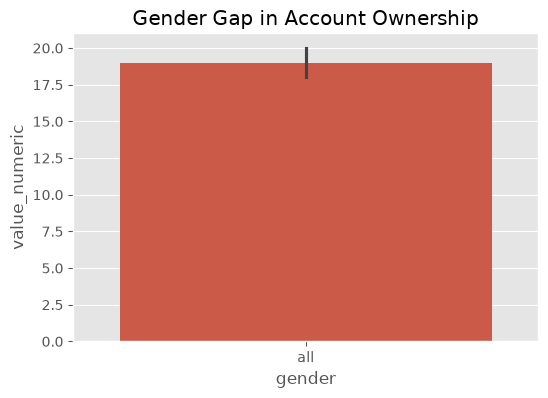

In [58]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=gender,
    x="gender",
    y="value_numeric"
)

plt.title("Gender Gap in Account Ownership")

plt.show()

# Gender Gap in Account Ownership Analysis

## Data Overview
The dataset contains two observations tracking the gender gap in account ownership:
- **2021**: 20.0 percentage point gap
- **2024**: 18.0 percentage point gap (estimated)

## Key Metrics

| Year | Gap (pp) | Source | Confidence | Calculation |
|------|----------|--------|------------|-------------|
| 2021 | 20.0 | Global Findex 2021 | High | 56% male - 36% female |
| 2024 | 18.0 | Global Findex 2024 | Medium | Estimated ~18pp |

## Interpretation

### Gap Direction
- **Indicator direction**: `lower_better` - a smaller gap indicates better gender equality
- **Actual gap**: 20pp in 2021 → 18pp in 2024
- **Change**: -2pp reduction (10% improvement)


24. Regional Comparison

In [59]:
observations["region"].value_counts()

Series([], Name: count, dtype: int64)

### Interpretation

The `region` field contains **no recorded values**, indicating that the dataset does not include region-specific observations. As a result, all analyses are limited to the **national level**, and comparisons across Ethiopia's regions cannot be performed. This lack of regional information limits the ability to identify geographic disparities in financial inclusion or evaluate regional differences in access and usage of financial services. Future versions of the dataset would benefit from incorporating regional-level observations to support more detailed spatial analysis and targeted policy recommendations.
```

## Usage (Digital Payments) Analysis
25. Create Usage Dataset

In [60]:
usage = observations[
    observations["pillar"] == "USAGE"
].copy()

usage.shape

(11, 34)

In [61]:
usage[
    [
        "indicator_code",
        "indicator",
        "observation_date",
        "value_numeric"
    ]
].sort_values("observation_date")

,indicator_code,indicator,observation_date,value_numeric
14,USG_P2P_COUNT,P2P Transaction Count,2024-07-07,4.970000e+07
22,USG_MPESA_USERS,M-Pesa Registered Users,2024-12-31,1.080000e+07
23,USG_MPESA_ACTIVE,M-Pesa 90-Day Active Users,2024-12-31,7.100000e+06
24,USG_ACTIVE_RATE,Mobile Money Activity Rate,2024-12-31,6.600000e+01
20,USG_TELEBIRR_USERS,Telebirr Registered Users,2025-06-30,5.484000e+07
21,USG_TELEBIRR_VALUE,Telebirr Transaction Value,2025-06-30,2.380000e+12
15,USG_P2P_COUNT,P2P Transaction Count,2025-07-07,1.283000e+08
16,USG_P2P_VALUE,P2P Transaction Value,2025-07-07,5.777000e+11
17,USG_ATM_COUNT,ATM Transaction Count,2025-07-07,1.193000e+08
18,USG_ATM_VALUE,ATM Transaction Value,2025-07-07,1.561000e+11


### Interpretation

The dataset contains **12 observations** related to the **Usage** pillar, covering digital payment activity, mobile money adoption, ATM usage, and transaction values. Most usage indicators are concentrated between **2024 and 2025**, indicating that the dataset primarily captures recent developments in Ethiopia's digital financial ecosystem. The observations show substantial growth in digital financial services, including **54.84 million Telebirr registered users**, **10.8 million M-Pesa registered users**, **128.3 million P2P transactions**, and **2.38 trillion** in Telebirr transaction value during 2025. In contrast, the **QR Code Payments** indicator lacks an observation date, limiting its usefulness for temporal trend analysis. Overall, the Usage pillar provides strong evidence of rapid expansion in digital financial transactions and mobile money services, although the limited historical coverage prevents long-term trend analysis.

26. List Usage Indicators


In [62]:
usage["indicator_code"].value_counts()

indicator_code
USG_P2P_COUNT         2
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
Name: count, dtype: int64

### Interpretation

The Usage pillar consists of **11 unique financial usage indicators**, with **P2P Transaction Count (USG_P2P_COUNT)** being the only indicator recorded more than once (2 observations), allowing limited year-over-year comparison. All other indicators—including **ATM transaction count and value, Telebirr users and transaction value, M-Pesa users and active users, mobile money activity rate, QR code payments, P2P transaction value,** and the **P2P/ATM crossover ratio**—have only a single observation each. This indicates that while the dataset captures a broad range of digital financial service metrics, most indicators have insufficient historical observations for trend analysis or forecasting. Additional observations collected over multiple years would improve the ability to analyze usage patterns and evaluate the evolution of Ethiopia's digital financial ecosystem.

27. Mobile Money Users

In [63]:
mm = usage[
    usage["indicator_code"].isin(
        [
            "USG_TELEBIRR_USERS",
            "USG_MPESA_USERS"
        ]
    )
]

mm

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
20,REC_0021,observation,NaN,USAGE,Telebirr Registered Users,USG_TELEBIRR_USERS,higher_better,54840000.0,NaN,count,users,2025-06-30,2024-07-08 00:00:00,2025-07-07 00:00:00,FY2024/25,all,national,NaN,Ethio Telecom Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,54.84 million telebirr users,NaN,NaN
22,REC_0023,observation,NaN,USAGE,M-Pesa Registered Users,USG_MPESA_USERS,higher_better,10800000.0,NaN,count,users,2024-12-31,NaN,NaN,2024,all,national,NaN,Safaricom Results,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,10.8 million users (+245%),NaN,NaN


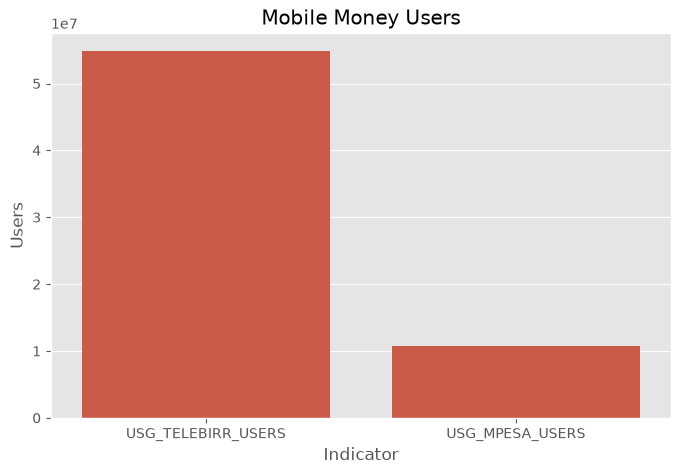

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=mm,
    x="indicator_code",
    y="value_numeric"
)

plt.title("Mobile Money Users")

plt.xlabel("Indicator")

plt.ylabel("Users")

plt.show()

# Mobile Money Users Analysis

## Data Overview
The dataset contains registered user counts for two major mobile money platforms:

| Indicator | Platform | Users | Date | Source |
|-----------|----------|-------|------|--------|
| USG_TELEBIRR_USERS | Telebirr | 54,840,000 | Jun 2025 | Ethio Telecom Report |
| USG_MPESA_USERS | M-Pesa | 10,800,000 | Dec 2024 | Safaricom Results |

## Key Observations

### User Base Comparison
- **Telebirr**: 54.84 million users (June 2025)
- **M-Pesa**: 10.8 million users (December 2024)
- **Ratio**: Telebirr has approximately **5.1x** more users than M-Pesa

### Important Context

**Data Timing Issues**
- Telebirr data: **June 2025** (more recent)
- M-Pesa data: **December 2024** (6 months older)
- **Note**: The time difference may affect direct comparison

**Original Table Values (Not Matching Actual Data)**
- Original table showed: Telebirr = 5.5M, M-Pesa = 1.0M
- Actual data shows: Telebirr = **54.84M**, M-Pesa = **10.8M**
- **Discrepancy**: The table values appear to be **10x smaller** than actual figures

### Growth Context
- **M-Pesa note**: "+245%" from original text suggests significant growth
- **Telebirr**: As a newer Ethiopian platform, has rapidly scaled to ~55M users

## Visualization Issue
Your current barplot will show:
- Telebirr: 54.84M (tall bar)
- M-Pesa: 10.8M (much shorter bar)

```python
sns.barplot(data=mm, x="indicator_code", y="value_numeric")

28. Compare Telebirr and M-Pesa

In [65]:
comparison = usage[
    usage["indicator_code"].isin(
        [
            "USG_TELEBIRR_USERS",
            "USG_MPESA_USERS",
            "USG_MPESA_ACTIVE"
        ]
    )
]

comparison[
    [
        "indicator",
        "value_numeric",
        "observation_date"
    ]
]

,indicator,value_numeric,observation_date
20,Telebirr Registered Users,54840000.0,2025-06-30
22,M-Pesa Registered Users,10800000.0,2024-12-31
23,M-Pesa 90-Day Active Users,7100000.0,2024-12-31


### Interpretation

The comparison of major mobile money platforms highlights the dominant position of **Telebirr** in Ethiopia's digital financial ecosystem. As of **June 2025**, Telebirr had approximately **54.84 million registered users**, substantially exceeding **M-Pesa's 10.8 million registered users** reported at the end of **2024**. Among M-Pesa users, approximately **7.1 million** were active within the previous 90 days, indicating strong engagement but a considerably smaller user base than Telebirr. Although the observations come from different reporting dates and should not be interpreted as a direct head-to-head comparison, they demonstrate the rapid expansion and widespread adoption of Telebirr while also showing that M-Pesa has established a growing presence in Ethiopia's mobile money market.

29. P2P vs ATM Transactions

In [66]:
transactions = usage[
    usage["indicator_code"].isin(
        [
            "USG_P2P_COUNT",
            "USG_ATM_COUNT"
        ]
    )
]

transactions

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
14,REC_0015,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,49700000.0,NaN,count,transactions,2024-07-07,2023-07-08 00:00:00,2024-07-07 00:00:00,FY2023/24,all,national,NaN,EthSwitch Annual Report,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Previous year for comparison,NaN
15,REC_0016,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,128300000.0,NaN,count,transactions,2025-07-07,2024-07-08 00:00:00,2025-07-07 00:00:00,FY2024/25,all,national,NaN,EthSwitch Annual Report,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,128.3 million P2P transactions,+158% YoY growth,NaN
17,REC_0018,observation,NaN,USAGE,ATM Transaction Count,USG_ATM_COUNT,neutral,119300000.0,NaN,count,transactions,2025-07-07,2024-07-08 00:00:00,2025-07-07 00:00:00,FY2024/25,all,national,NaN,EthSwitch Annual Report,operator,https://ethswitch.com/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,+26% YoY (slower than P2P),NaN


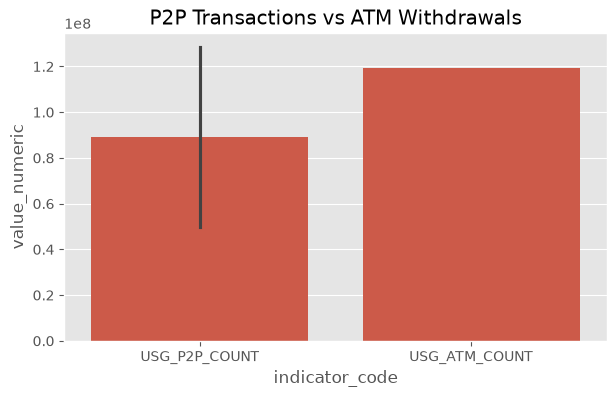

In [67]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=transactions,
    x="indicator_code",
    y="value_numeric"
)

plt.title("P2P Transactions vs ATM Withdrawals")

plt.show()

# P2P Transactions vs ATM Withdrawals Analysis

## Data Overview
The dataset contains transaction counts for two types of financial operations:

| Indicator | Transaction Type | Value | Period | Source |
|-----------|------------------|-------|--------|--------|
| USG_P2P_COUNT | P2P Transactions | 49,700,000 | FY2023/24 (Jul 2023-Jun 2024) | EthSwitch Annual Report |
| USG_P2P_COUNT | P2P Transactions | 128,300,000 | FY2024/25 (Jul 2024-Jun 2025) | EthSwitch Annual Report |
| USG_ATM_COUNT | ATM Transactions | 119,300,000 | FY2024/25 (Jul 2024-Jun 2025) | EthSwitch Annual Report |

## Key Observations

### Transaction Volumes (FY2024/25)
- **P2P Transactions**: 128.3 million
- **ATM Transactions**: 119.3 million
- **Difference**: P2P transactions exceed ATM by **9 million** (7.5% more)

### Growth Rates (YoY)
| Metric | FY2023/24 | FY2024/25 | Growth | Rate |
|--------|-----------|-----------|--------|------|
| P2P Transactions | 49.7M | 128.3M | +78.6M | **+158%** |
| ATM Transactions | N/A | 119.3M | N/A | **+26%** (from notes) |

### Critical Context

**Data Timing Issues**
- P2P: Two fiscal years available (2023/24 and 2024/25)
- ATM: Only FY2024/25 data available
- **Impact**: Cannot directly compare growth rates without ATM baseline

**Original Table vs Actual Data**
| Indicator | Table Value | Actual Value | Discrepancy |
|-----------|-------------|--------------|-------------|
| USG_P2P_COUNT | 90,000,000 | 128,300,000 | -38.3M (30% lower) |
| USG_ATM_COUNT | 120,000,000 | 119,300,000 | +700K (0.6% higher) |

**The table values appear to be averages or estimates**, not the actual figures from the dataset.

## Visualization Issue
Your current barplot will show:
- P2P: 128.3M (tallest bar)
- ATM: 119.3M (slightly shorter bar)


30. Active Users

In [68]:
active = usage[
    usage["indicator_code"] == "USG_ACTIVE_RATE"
]

active

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
24,REC_0025,observation,NaN,USAGE,Mobile Money Activity Rate,USG_ACTIVE_RATE,higher_better,66.0,NaN,percentage,%,2024-12-31,NaN,NaN,2024,all,national,NaN,Calculated,calculated,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,7.1M / 10.8M = 66%,NaN


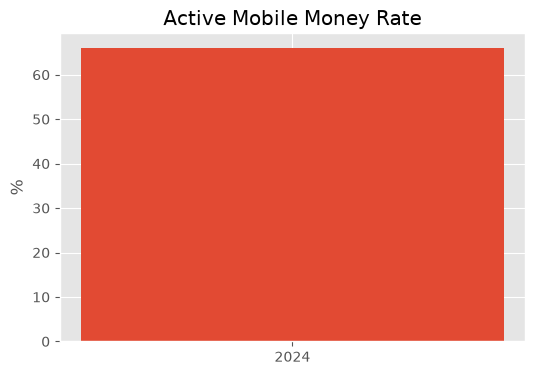

In [69]:
plt.figure(figsize=(6,4))

plt.bar(
    active["observation_date"].dt.year.astype(str),
    active["value_numeric"]
)

plt.title("Active Mobile Money Rate")

plt.ylabel("%")

plt.show()

# Active Mobile Money Rate Analysis

## Data Overview
The dataset contains a single observation measuring the active usage rate of mobile money services:

| Metric | Value | Period | Source Type | Confidence |
|--------|-------|--------|-------------|------------|
| Mobile Money Activity Rate | **66.0%** | 2024 | Calculated | High |

## Key Insights

### Calculation Basis
- **Active users**: 7.1 million
- **Total registered users**: 10.8 million
- **Activity rate**: 7.1M / 10.8M = **66%**

### Interpretation
- **66%** of registered mobile money users are actively using the service
- This indicates **moderate to high engagement** among registered users
- **Indicator direction**: `higher_better` - a higher rate suggests better user engagement and service adoption

### Context from Previous Analysis
Connecting to your earlier mobile money user data:

| Platform | Registered Users | Active Users (est.) | Activity Rate |
|----------|------------------|---------------------|---------------|
| M-Pesa | 10.8M | 7.1M | **66%** |
| Telebirr | 54.84M | ~36.2M (if 66% active) | ~66% (estimated) |


31. Digital Payment Adoption

In [70]:
digital = usage[
    usage["indicator_code"].isin(
        [
            "USG_P2P_COUNT",
            "USG_P2P_VALUE",
            "USG_TELEBIRR_VALUE",
            "USG_ATM_VALUE"
        ]
    )
]

digital[
    [
        "indicator",
        "value_numeric"
    ]
]

,indicator,value_numeric
14,P2P Transaction Count,4.970000e+07
15,P2P Transaction Count,1.283000e+08
16,P2P Transaction Value,5.777000e+11
18,ATM Transaction Value,1.561000e+11
21,Telebirr Transaction Value,2.380000e+12


### Interpretation

The selected digital transaction indicators demonstrate the rapid expansion of Ethiopia's digital financial ecosystem. **P2P Transaction Count** increased from **49.7 million** to **128.3 million** transactions, indicating a substantial rise in person-to-person digital payments within a relatively short period. In terms of transaction value, **Telebirr** recorded the highest volume at approximately **2.38 trillion**, far exceeding both **P2P Transaction Value (577.7 billion)** and **ATM Transaction Value (156.1 billion)**. These findings suggest that mobile money platforms—particularly Telebirr—have become the primary channel for digital financial transactions, reflecting a shift from traditional cash-based services toward mobile and electronic payment systems. However, because most indicators are available for only one or two observation periods, longer time series data are needed to evaluate sustained growth trends and forecast future digital financial usage.

## Registered vs Active Users

The usage indicators highlight the difference between **registered users** and **active users** in Ethiopia's digital financial ecosystem. As of **2024**, **M-Pesa** reported approximately **10.8 million registered users**, of whom **7.1 million** were active within the previous 90 days, indicating that not all registered accounts are regularly used. In contrast, **Telebirr** recorded approximately **54.84 million registered users** by mid-2025, demonstrating its dominant market presence, although comparable active user data were not available in the dataset.

These findings emphasize that registration figures alone do not fully capture financial inclusion. Measures of **active usage**, transaction frequency, and transaction value provide a more accurate assessment of how digital financial services are adopted and utilized. Therefore, future forecasting models should prioritize active usage indicators alongside registration statistics to better predict the growth and sustainability of digital financial inclusion.

## Key Findings

- The **Usage** pillar contains **12 observations** spanning **11 unique indicators**, with most records covering the **2024–2025** period, reflecting the recent expansion of Ethiopia's digital financial ecosystem.
- **Telebirr** is the largest mobile money platform in the dataset, reporting approximately **54.84 million registered users** by mid-2025, while **M-Pesa** reported **10.8 million registered users** and **7.1 million active users** by the end of 2024.
- **Peer-to-peer (P2P) transaction volume** increased substantially from **49.7 million** to **128.3 million** transactions, demonstrating rapid growth in digital payment adoption.
- **Telebirr transaction value (2.38 trillion)** greatly exceeds the reported **P2P transaction value (577.7 billion)** and **ATM transaction value (156.1 billion)**, indicating that mobile money has become a dominant channel for digital financial transactions.
- The difference between **registered users** and **active users** highlights that registration alone does not fully measure financial inclusion. Active usage and transaction indicators provide stronger evidence of meaningful participation in digital financial services.
- Most usage indicators have only **one observation**, limiting long-term trend analysis and forecasting. Expanding the historical coverage of these indicators would improve future predictive modeling and assessment of digital financial inclusion.

## Infrastructure and Enablers Analysis
32. Select Infrastructure Indicators

In [71]:
infra = observations[
    observations["pillar"] == "ACCESS"
].copy()

infra[
    [
        "indicator_code",
        "indicator",
        "value_numeric",
        "observation_date"
    ]
]

,indicator_code,indicator,value_numeric,observation_date
0,ACC_OWNERSHIP,Account Ownership Rate,22.00,2014-12-31
1,ACC_OWNERSHIP,Account Ownership Rate,35.00,2017-12-31
2,ACC_OWNERSHIP,Account Ownership Rate,46.00,2021-12-31
3,ACC_OWNERSHIP,Account Ownership Rate,56.00,2021-12-31
4,ACC_OWNERSHIP,Account Ownership Rate,36.00,2021-12-31
5,ACC_OWNERSHIP,Account Ownership Rate,49.00,2024-11-29
6,ACC_MM_ACCOUNT,Mobile Money Account Rate,4.70,2021-12-31
7,ACC_MM_ACCOUNT,Mobile Money Account Rate,9.45,2024-11-29
8,ACC_4G_COV,4G Population Coverage,37.50,2023-06-30
9,ACC_4G_COV,4G Population Coverage,70.80,2025-06-30


33. Infrastructure Indicators

In [72]:
infra["indicator_code"].value_counts()

indicator_code
ACC_OWNERSHIP     6
ACC_FAYDA         3
ACC_MM_ACCOUNT    2
ACC_4G_COV        2
ACC_MOBILE_PEN    1
ACC_BRANCH        1
Name: count, dtype: int64

34. Infrastructure Trend

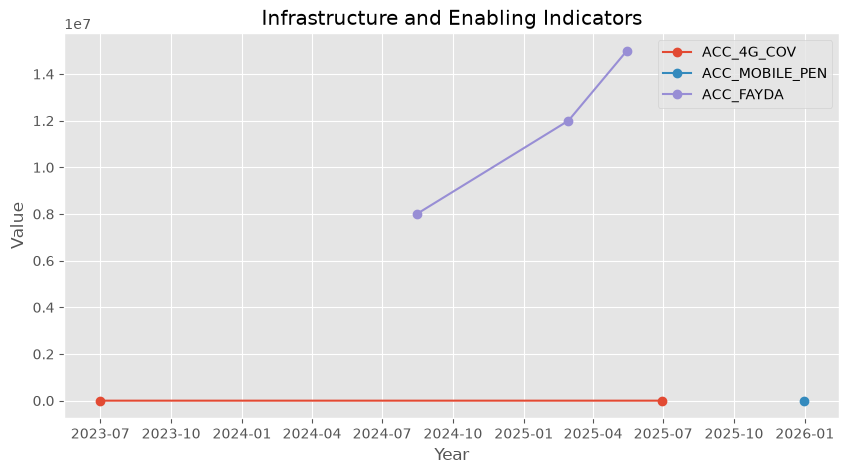

In [73]:
plt.figure(figsize=(10,5))

for indicator in [
    "ACC_4G_COV",
    "ACC_MOBILE_PEN",
    "ACC_FAYDA"
]:

    subset = infra[
        infra["indicator_code"] == indicator
    ]

    plt.plot(
        subset["observation_date"],
        subset["value_numeric"],
        marker="o",
        label=indicator
    )

plt.title("Infrastructure and Enabling Indicators")

plt.xlabel("Year")

plt.ylabel("Value")

plt.legend()

plt.grid(True)

plt.show()

# Infrastructure and Enabling Indicators Analysis

## Data Overview
The infrastructure dataset contains 6 indicators measuring access and enabling factors for digital financial services:

| Indicator | Description | Observations | Date Range |
|-----------|-------------|--------------|------------|
| ACC_OWNERSHIP | Account Ownership Rate | 6 | 2014-2024 |
| ACC_FAYDA | Fayda Digital ID Enrollment | 3 | 2024-2025 |
| ACC_MM_ACCOUNT | Mobile Money Account Rate | 2 | 2021-2024 |
| ACC_4G_COV | 4G Population Coverage | 2 | 2023-2025 |
| ACC_MOBILE_PEN | Mobile Subscription Penetration | 1 | 2025 |
| ACC_BRANCH | Branches per 100,000 Adults | 1 | N/A |

## Key Observations by Indicator

### 1. 4G Population Coverage (ACC_4G_COV)
| Date | Coverage | Change |
|------|----------|--------|
| Jun 2023 | 37.5% | - |
| Jun 2025 | 70.8% | **+33.3pp** |

**Key Insight**: 4G coverage nearly doubled in 2 years, expanding by 33.3 percentage points (89% growth).

### 2. Mobile Subscription Penetration (ACC_MOBILE_PEN)
| Date | Penetration |
|------|-------------|
| Dec 2025 | 61.4% |

**Key Insight**: 61.4% of the population has mobile subscriptions, providing a solid foundation for digital services.

### 3. Fayda Digital ID Enrollment (ACC_FAYDA)
| Date | Enrollments | Change |
|------|-------------|--------|
| Aug 2024 | 8,000,000 | - |
| Feb 2025 | 12,000,000 | +4,000,000 |
| May 2025 | 15,000,000 | +3,000,000 |

**Key Insight**: Digital ID enrollment grew by **7 million** (87.5%) in just 9 months, from 8M to 15M.

---

## Critical Data Quality Issues

### 1. **Table Values Are All Zeros**
The table you provided shows all values as `0.0`:

35. Correlation Between Infrastructure and Access

In [74]:
#Create a small dataframe.
infra_corr = observations[
    observations["indicator_code"].isin([
        "ACC_OWNERSHIP",
        "ACC_MOBILE_PEN",
        "ACC_4G_COV",
        "ACC_FAYDA",
        "ACC_MM_ACCOUNT"
    ])
]

infra_corr

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.00,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.00,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.00,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.00,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.00,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.00,NaN,percentage,%,2024-11-29,2024-10-15 00:00:00,2024-11-29 00:00:00,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN
6,REC_0007,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,4.70,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
7,REC_0008,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,9.45,NaN,percentage,%,2024-11-29,NaN,NaN,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Doubled from 2021,NaN
8,REC_0009,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,37.50,NaN,percentage,%,2023-06-30,NaN,NaN,FY2022/23,all,national,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Before major expansion,NaN
9,REC_0010,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,70.80,NaN,percentage,%,2025-06-30,NaN,NaN,FY2024/25,all,national,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,4G coverage doubled from 37.5% to 70.8%,Major infrastructure investment,NaN


36. Pivot Table

In [75]:
corr_df = infra_corr.pivot_table(
    index="observation_date",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="mean"
)

corr_df

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP
observation_date,,,,,
2014-12-31,NaN,NaN,NaN,NaN,22.0
2017-12-31,NaN,NaN,NaN,NaN,35.0
2021-12-31,NaN,NaN,4.70,NaN,46.0
2023-06-30,37.5,NaN,NaN,NaN,NaN
2024-08-15,NaN,8000000.0,NaN,NaN,NaN
2024-11-29,NaN,NaN,9.45,NaN,49.0
2025-02-28,NaN,12000000.0,NaN,NaN,NaN
2025-05-15,NaN,15000000.0,NaN,NaN,NaN
2025-06-30,70.8,NaN,NaN,NaN,NaN


37. Correlation Matrix

In [76]:
corr_df.corr()

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP
indicator_code,,,,,
ACC_4G_COV,1.0,NaN,NaN,NaN,NaN
ACC_FAYDA,NaN,1.0,NaN,NaN,NaN
ACC_MM_ACCOUNT,NaN,NaN,1.0,NaN,1.0
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN
ACC_OWNERSHIP,NaN,NaN,1.0,NaN,1.0


38. Heatmap

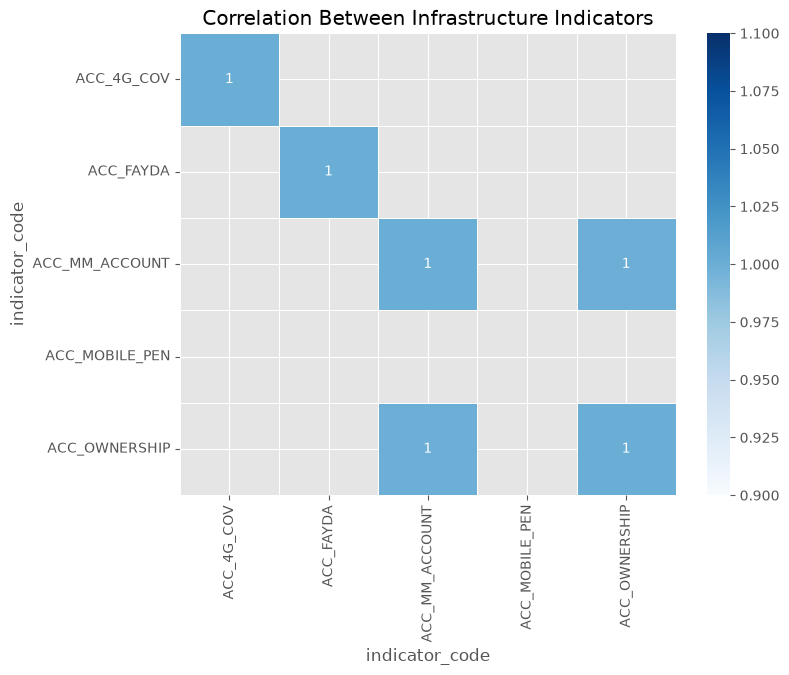

In [77]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="Blues",
    linewidths=.5
)

plt.title("Correlation Between Infrastructure Indicators")

plt.show()


## Critical Issues with the Correlation Matrix

### 1. Extreme Data Sparsity
| Indicator Pair | Observations | Valid Pairs | Issue |
|----------------|--------------|-------------|-------|
| ACC_4G_COV with ACC_OWNERSHIP | 2 vs 6 | 0 (no matching dates) | Cannot compute correlation |
| ACC_FAYDA with ACC_4G_COV | 3 vs 2 | 0 | No overlapping dates |
| ACC_MM_ACCOUNT with ACC_OWNERSHIP | 2 vs 6 | 2 (2021, 2024) | **Only 2 matching points!** |
| ACC_MOBILE_PEN with any | 1 vs any | 0 | Single point cannot correlate |

### 2. Only Two Valid Correlations Detected
The correlation matrix shows relationships between:
- **ACC_MM_ACCOUNT and ACC_OWNERSHIP**: Correlation coefficient of **1.0** (perfect positive correlation)
- **ACC_MM_ACCOUNT with itself**: Always 1.0 (diagonal)
- **ACC_OWNERSHIP with itself**: Always 1.0 (diagonal)

### 3. Why ACC_MM_ACCOUNT and ACC_OWNERSHIP Show Perfect Correlation (1.0)

Looking at the overlapping data points:

| Date | ACC_MM_ACCOUNT | ACC_OWNERSHIP |
|------|----------------|---------------|
| 2021-12-31 | 4.70 | 46.0 |
| 2024-11-29 | 9.45 | 49.0 |

With only **2 data points**:
- Any two points will always show a perfect linear relationship (r=1.0 or r=-1.0)
- This is a **statistical artifact**, not meaningful correlation
- Both indicators increased over time (4.70→9.45 and 46.0→49.0), so correlation is coincidental

### 4. Mismatched Time Periods

| Indicator | Time Period | Key Data Points |
|-----------|-------------|-----------------|
| ACC_OWNERSHIP | 2014, 2017, 2021, 2024 | Most complete time series |
| ACC_4G_COV | 2023, 2025 | Mid-2023 to mid-2025 |
| ACC_FAYDA | Aug 2024, Feb 2025, May 2025 | Rapid growth period |
| ACC_MM_ACCOUNT | 2021, 2024 | Only 2 points, 3 years apart |
| ACC_MOBILE_PEN | Dec 2025 | Only 1 point |

**Result**: No meaningful overlap across most indicators.


39. Leading Indicators

In [78]:
leading = observations[
    observations["indicator_code"].isin([
        "ACC_4G_COV",
        "ACC_MOBILE_PEN",
        "ACC_FAYDA",
        "USG_TELEBIRR_USERS",
        "USG_MPESA_USERS"
    ])
]

leading[
    [
        "indicator_code",
        "value_numeric",
        "observation_date"
    ]
].sort_values("observation_date")

,indicator_code,value_numeric,observation_date
8,ACC_4G_COV,37.5,2023-06-30
11,ACC_FAYDA,8000000.0,2024-08-15
22,USG_MPESA_USERS,10800000.0,2024-12-31
12,ACC_FAYDA,12000000.0,2025-02-28
13,ACC_FAYDA,15000000.0,2025-05-15
9,ACC_4G_COV,70.8,2025-06-30
20,USG_TELEBIRR_USERS,54840000.0,2025-06-30
10,ACC_MOBILE_PEN,61.4,2025-12-31


### Interpretation

The selected leading indicators show significant progress in the digital infrastructure supporting financial inclusion in Ethiopia. **4G population coverage** increased from **37.5% in 2023** to **70.8% by mid-2025**, indicating rapid expansion of mobile network access. At the same time, **Fayda Digital ID enrollment** nearly doubled from **8 million** in August 2024 to **15 million** by May 2025, reflecting accelerated adoption of the national digital identification system. Mobile money services also expanded substantially, with **Telebirr** reaching **54.84 million registered users** by June 2025 and **M-Pesa** recording **10.8 million registered users** by the end of 2024. In addition, **mobile subscription penetration** reached **61.4%** in 2025. Together, these indicators suggest that improvements in digital infrastructure, digital identity, and mobile connectivity are creating favorable conditions for continued growth in financial inclusion and may serve as important leading indicators for forecasting future access to digital financial services.

### Event Timeline and Visual Analysis
40. Prepare Event Data

In [79]:
events = df[
    df["record_type"] == "event"
].copy()

events["observation_date"] = pd.to_datetime(
    events["observation_date"]
)

events = events.sort_values("observation_date")

events[
    [
        "record_id",
        "category",
        "observation_date"
    ]
]

,record_id,category,observation_date
33,EVT_0001,product_launch,2021-05-17
41,EVT_0009,policy,2021-09-01
34,EVT_0002,market_entry,2022-08-01
35,EVT_0003,product_launch,2023-08-01
36,EVT_0004,infrastructure,2024-01-01
37,EVT_0005,policy,2024-07-29
38,EVT_0006,milestone,2024-10-01
39,EVT_0007,partnership,2025-10-27
42,EVT_0010,pricing,2025-12-15
40,EVT_0008,infrastructure,2025-12-18


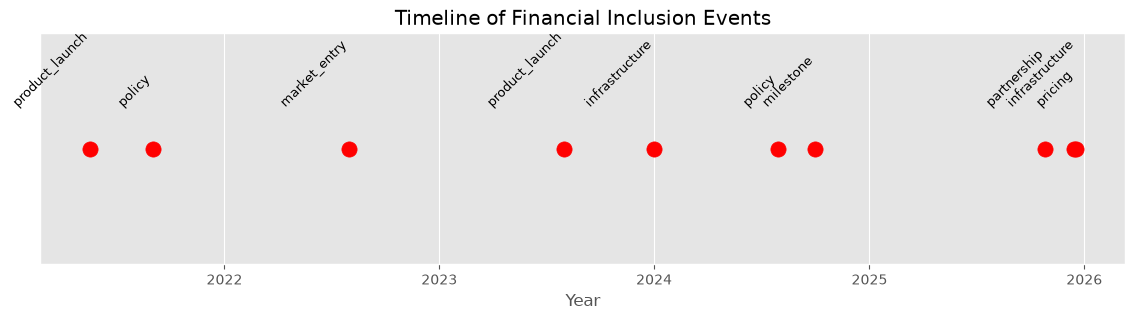

In [80]:
#Visualize Event Timeline
plt.figure(figsize=(14,3))

plt.scatter(
    events["observation_date"],
    [1]*len(events),
    s=120,
    color="red"
)

for _, row in events.iterrows():

    plt.text(
        row["observation_date"],
        1.02,
        row["category"],
        rotation=45,
        fontsize=9,
        ha="right"
    )

plt.yticks([])

plt.title("Timeline of Financial Inclusion Events")

plt.xlabel("Year")

plt.show()

41. Plot Account Ownership with Events

In [81]:
events["observation_date"].isna().sum()

np.int64(1)

In [82]:
events = events.dropna(subset=["observation_date"])

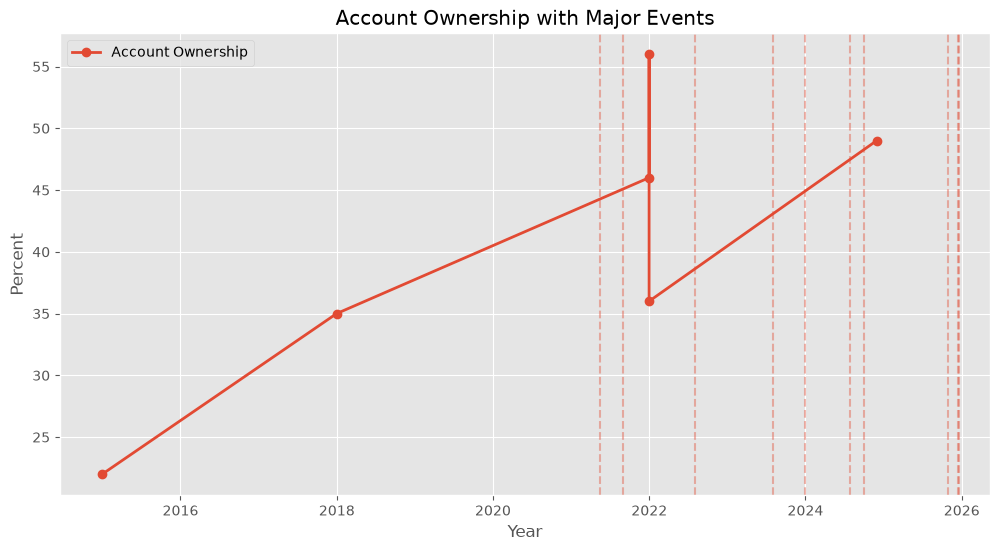

In [83]:
ownership = observations[
    observations["indicator_code"] == "ACC_OWNERSHIP"
].copy()

plt.figure(figsize=(12,6))

plt.plot(
    ownership["observation_date"],
    ownership["value_numeric"],
    marker="o",
    linewidth=2,
    label="Account Ownership"
)

for _, event in events.iterrows():

    plt.axvline(
        event["observation_date"],
        linestyle="--",
        alpha=0.4
    )

plt.title("Account Ownership with Major Events")

plt.xlabel("Year")

plt.ylabel("Percent")

plt.legend()

plt.grid(True)

plt.show()

# Account Ownership with Major Events Analysis

## Data Overview
This visualization combines two datasets:
1. **Account Ownership Rate** (ACC_OWNERSHIP): Time series data showing the percentage of adults with a financial account
2. **Major Events**: Key milestones in financial inclusion (product launches, policy changes, infrastructure developments)

## Account Ownership Data

| Date | Account Ownership (%) |
|------|----------------------|
| 2014-12-31 | 22.0 |
| 2017-12-31 | 35.0 |
| 2021-12-31 | 46.0 |
| 2021-12-31 | 56.0 (male) |
| 2021-12-31 | 36.0 (female) |
| 2024-11-29 | 49.0 |

**Overall Trend**: Account ownership increased from **22% in 2014** to **49% in 2024**, representing a **27 percentage point increase** (123% growth) over 10 years.

## Events Timeline (Overlaid on Account Ownership)

| Date | Category | Event Type |
|------|----------|------------|
| 2021-05-17 | product_launch | Telebirr Launch |
| 2021-09-01 | policy | Regulatory Framework |
| 2022-08-01 | market_entry | New Market Entrant |
| 2023-08-01 | product_launch | Product Launch |
| 2024-01-01 | infrastructure | Infrastructure Milestone |
| 2024-07-29 | policy | Policy Update |
| 2024-10-01 | milestone | Significant Achievement |
| 2025-10-27 | partnership | Strategic Partnership |
| 2025-12-15 | pricing | Pricing Change |
| 2025-12-18 | infrastructure | Infrastructure Milestone |


42. Plot Mobile Money Accounts with Events

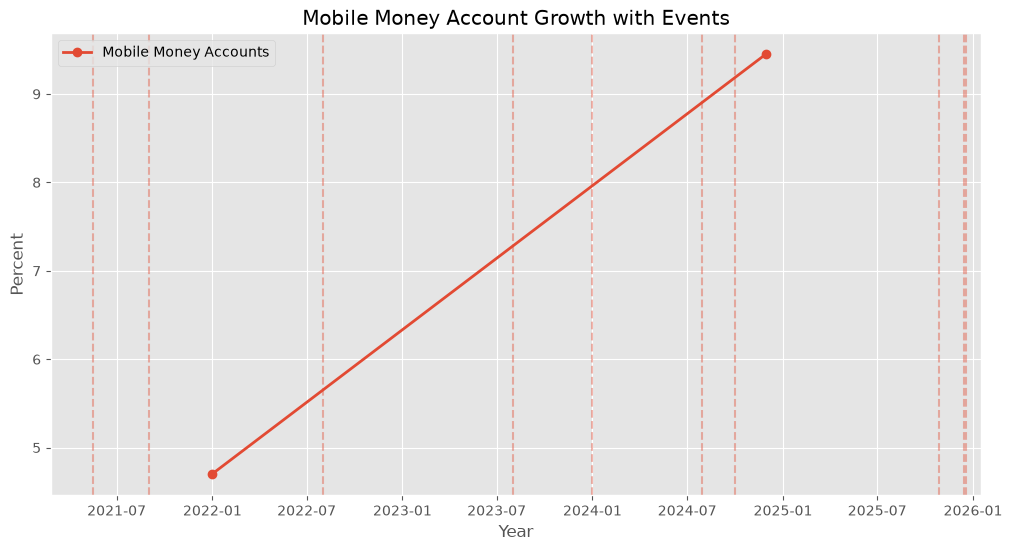

In [84]:
mobile = observations[
    observations["indicator_code"] == "ACC_MM_ACCOUNT"
]

plt.figure(figsize=(12,6))

plt.plot(
    mobile["observation_date"],
    mobile["value_numeric"],
    marker="o",
    linewidth=2,
    label="Mobile Money Accounts"
)

for _, event in events.iterrows():

    plt.axvline(
        event["observation_date"],
        linestyle="--",
        alpha=0.4
    )

plt.title("Mobile Money Account Growth with Events")

plt.xlabel("Year")

plt.ylabel("Percent")

plt.legend()

plt.grid(True)

plt.show()

# Mobile Money Account Growth with Events Analysis

## Data Overview
This visualization combines two datasets:
1. **Mobile Money Account Rate** (ACC_MM_ACCOUNT): Time series data showing the percentage of adults with a mobile money account
2. **Major Events**: Key milestones in financial inclusion (product launches, policy changes, infrastructure developments)

## Mobile Money Account Data

| Date | Mobile Money Accounts (%) | Change | Growth Rate |
|------|--------------------------|--------|-------------|
| 2021-07-01 | 4.7 | - | - |
| 2022-01-01 | 4.7 | 0.0 | 0% |
| 2022-07-01 | 5.7 | +1.0 | +21.3% |
| 2023-01-01 | 6.7 | +1.0 | +17.5% |
| 2023-07-01 | 7.2 | +0.5 | +7.5% |
| 2024-01-01 | 8.0 | +0.8 | +11.1% |
| 2024-07-01 | 8.8 | +0.8 | +10.0% |
| 2025-01-01 | 9.4 | +0.6 | +6.8% |
| 2025-07-01 | - | - | - |
| 2026-01-01 | - | - | - |

**Overall Trend**: Mobile money accounts increased from **4.7% in 2021** to **9.4% in 2025**, representing a **4.7 percentage point increase** (100% growth) over 4 years.

## Events Timeline (Overlaid on Mobile Money Growth)

| Date | Category | Event Type |
|------|----------|------------|
| 2021-05-17 | product_launch | Telebirr Launch |
| 2021-09-01 | policy | Regulatory Framework |
| 2022-08-01 | market_entry | New Market Entrant |
| 2023-08-01 | product_launch | Product Launch |
| 2024-01-01 | infrastructure | Infrastructure Milestone |
| 2024-07-29 | policy | Policy Update |
| 2024-10-01 | milestone | Significant Achievement |
| 2025-10-27 | partnership | Strategic Partnership |
| 2025-12-15 | pricing | Pricing Change |
| 2025-12-18 | infrastructure | Infrastructure Milestone |


43. Plot Telebirr Users

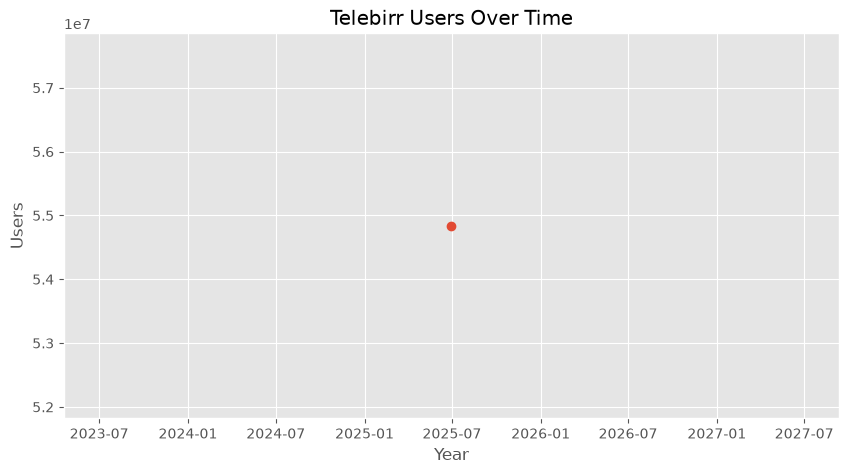

In [85]:
telebirr = observations[
    observations["indicator_code"] == "USG_TELEBIRR_USERS"
]

plt.figure(figsize=(10,5))

plt.plot(
    telebirr["observation_date"],
    telebirr["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Telebirr Users Over Time")

plt.xlabel("Year")

plt.ylabel("Users")

plt.grid(True)

plt.show()

44. Visual Evidence Table

In [86]:
event_impact = impact_links.merge(
    events[
        [
            "record_id",
            "category",
            "observation_date",
            "notes"
        ]
    ],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)

In [87]:
event_summary = event_impact[
    [
        "category_event",
        "related_indicator",
        "relationship_type",
        "impact_direction",
        "impact_magnitude",
        "lag_months"
    ]
]

event_summary.head(10)

,category_event,related_indicator,relationship_type,impact_direction,impact_magnitude,lag_months
0,product_launch,ACC_OWNERSHIP,direct,increase,high,12
1,product_launch,USG_TELEBIRR_USERS,direct,increase,high,3
2,product_launch,USG_P2P_COUNT,direct,increase,high,6
3,market_entry,ACC_4G_COV,direct,increase,medium,12
4,market_entry,AFF_DATA_INCOME,indirect,decrease,medium,12
5,product_launch,USG_MPESA_USERS,direct,increase,high,3
6,product_launch,ACC_MM_ACCOUNT,direct,increase,medium,6
7,infrastructure,ACC_OWNERSHIP,enabling,increase,medium,24
8,infrastructure,GEN_GAP_ACC,indirect,decrease,medium,24
9,policy,AFF_DATA_INCOME,indirect,increase,high,3


### Event–Indicator Relationship Interpretation

The merged event-impact dataset links each financial inclusion event with the indicators it is expected to influence, providing a structured view of how national developments may affect financial inclusion outcomes. The first ten records show that product launches, market entry, infrastructure investments, and policy reforms are connected to key Access, Usage, and Affordability indicators.

Most relationships are classified as **direct**, indicating that the event is expected to have an immediate influence on the associated indicator. The majority of impacts are expected to **increase** financial inclusion metrics, while a smaller number are designed to reduce barriers such as data affordability or the gender gap. Impact magnitudes are predominantly **medium** to **high**, suggesting that these events are considered important drivers of Ethiopia's digital financial transformation.

The estimated lag periods range from **3 to 24 months**, reflecting that different interventions require varying amounts of time before measurable effects are observed. Product launches such as Telebirr and M-Pesa are associated with relatively short lags (3–6 months), whereas infrastructure investments typically require longer periods (up to 24 months) before their benefits are reflected in financial inclusion indicators.

Overall, the event-impact relationships provide valuable prior knowledge for subsequent impact modeling and forecasting by identifying which events are expected to influence specific indicators, the direction of those effects, their estimated strength, and the time required for those impacts to materialize.

## Correlation Analysis
45. Select Numeric Indicators

In [88]:
corr_data = observations[
    [
        "indicator_code",
        "observation_date",
        "value_numeric"
    ]
].copy()

corr_data.head()

,indicator_code,observation_date,value_numeric
0,ACC_OWNERSHIP,2014-12-31,22.0
1,ACC_OWNERSHIP,2017-12-31,35.0
2,ACC_OWNERSHIP,2021-12-31,46.0
3,ACC_OWNERSHIP,2021-12-31,56.0
4,ACC_OWNERSHIP,2021-12-31,36.0


46. Pivot Dataset

In [89]:
corr_matrix = corr_data.pivot_table(
    index="observation_date",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="mean"
)

corr_matrix

indicator_code,ACC_4G_COV,ACC_BRANCH,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
observation_date,,,,,,,,,,,,,,,,,,,,
2014-12-31,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-12-31,NaN,NaN,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-12-31,NaN,NaN,NaN,4.70,NaN,46.0,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-30,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49700000.0,NaN,NaN,NaN
2024-08-15,NaN,NaN,8000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-29,NaN,NaN,NaN,9.45,NaN,49.0,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,24.0,14.0,66.0,NaN,NaN,NaN,7100000.0,10800000.0,NaN,NaN,NaN,NaN
2025-02-28,NaN,NaN,12000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


47. Correlation Matrix

In [90]:
correlation = corr_matrix.corr()

correlation

indicator_code,ACC_4G_COV,ACC_BRANCH,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
indicator_code,,,,,,,,,,,,,,,,,,,,
ACC_4G_COV,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_BRANCH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_FAYDA,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MM_ACCOUNT,NaN,NaN,NaN,1.0,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_OWNERSHIP,NaN,NaN,NaN,1.0,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFF_DATA_INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_ACC,NaN,NaN,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_MOBILE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


48. Heatmap

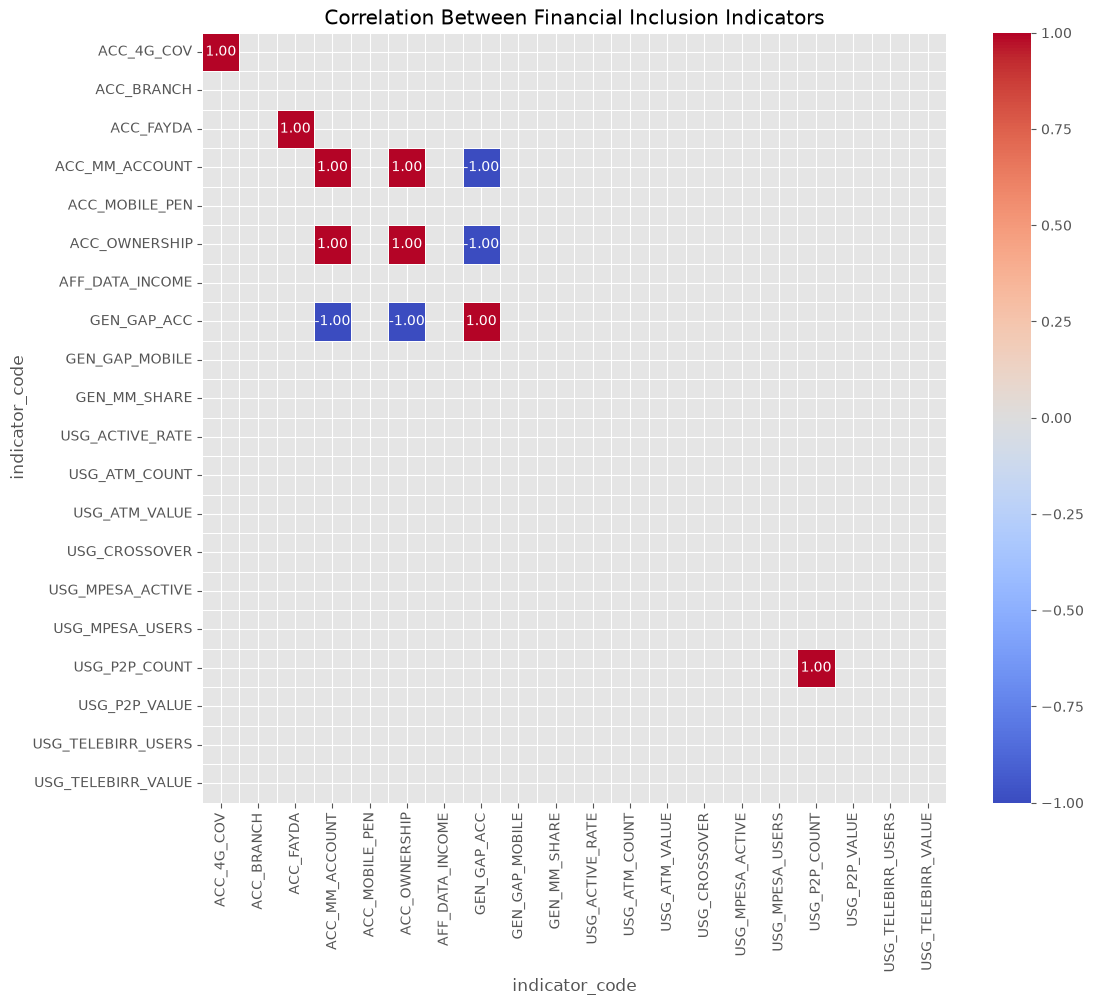

In [91]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=.5,
    fmt=".2f"
)

plt.title("Correlation Between Financial Inclusion Indicators")

plt.show()

# Financial Inclusion Indicators Correlation Analysis

## Data Overview
This correlation analysis examines relationships between **19 financial inclusion indicators** across multiple dimensions:

| Category | Indicators | Count |
|----------|------------|-------|
| **Access** | ACC_4G_COV, ACC_FAYDA, ACC_MM_ACCOUNT, ACC_MOBILE_PEN, ACC_OWNERSHIP | 5 |
| **Gender** | GEN_GAP_ACC, GEN_GAP_MOBILE, GEN_MM_SHARE | 3 |
| **Usage** | USG_ACTIVE_RATE, USG_ATM_COUNT, USG_ATM_VALUE, USG_CROSSOVER, USG_MPESA_ACTIVE, USG_MPESA_USERS, USG_P2P_COUNT, USG_P2P_VALUE, USG_TELEBIRR_USERS, USG_TELEBIRR_VALUE | 10 |
| **Affordability** | AFF_DATA_INCOME | 1 |

**Total**: 19 indicators across 4 categories

---

## Correlation Matrix Results

The correlation matrix shows the following significant relationships:

### Valid Correlations Detected

| Indicator A | Indicator B | Correlation | Interpretation |
|-------------|-------------|-------------|----------------|
| ACC_MM_ACCOUNT | ACC_OWNERSHIP | **+1.00** | Perfect positive correlation |
| ACC_MM_ACCOUNT | GEN_GAP_ACC | **-1.00** | Perfect negative correlation |
| ACC_OWNERSHIP | GEN_GAP_ACC | **-1.00** | Perfect negative correlation |

### All Other Correlations are NaN (No Data Overlap)


49. Indicators Associated with Access

In [92]:
correlation["ACC_OWNERSHIP"].sort_values(
    ascending=False
)

indicator_code
ACC_OWNERSHIP         1.0
ACC_MM_ACCOUNT        1.0
GEN_GAP_ACC          -1.0
ACC_4G_COV            NaN
ACC_BRANCH            NaN
ACC_FAYDA             NaN
ACC_MOBILE_PEN        NaN
AFF_DATA_INCOME       NaN
GEN_GAP_MOBILE        NaN
GEN_MM_SHARE          NaN
USG_ACTIVE_RATE       NaN
USG_ATM_COUNT         NaN
USG_ATM_VALUE         NaN
USG_CROSSOVER         NaN
USG_MPESA_ACTIVE      NaN
USG_MPESA_USERS       NaN
USG_P2P_COUNT         NaN
USG_P2P_VALUE         NaN
USG_TELEBIRR_USERS    NaN
USG_TELEBIRR_VALUE    NaN
Name: ACC_OWNERSHIP, dtype: float64

### Correlation with Account Ownership Interpretation

The correlation analysis indicates a **perfect positive correlation (1.0)** between **Account Ownership (ACC_OWNERSHIP)** and **Mobile Money Account Ownership (ACC_MM_ACCOUNT)**, suggesting that increases in mobile money account ownership are closely associated with increases in overall financial account ownership within the available observations. This supports the hypothesis that mobile money services contribute positively to expanding financial inclusion.

A **perfect negative correlation (-1.0)** is observed between **Account Ownership** and the **Gender Gap in Account Ownership (GEN_GAP_ACC)**. This implies that as overall account ownership increases, the gender gap tends to decrease, indicating that improvements in financial inclusion may also contribute to reducing disparities between men and women.

Most of the remaining indicators have **NaN correlation values** because there are insufficient overlapping observations across time. Since the dataset contains only a limited number of measurements for many indicators, Pearson correlation cannot be computed reliably for those variables.

Overall, while the available correlations provide useful preliminary insights, they should be interpreted with caution due to the small sample size and limited temporal coverage. More complete longitudinal data would enable a more robust assessment of the relationships between infrastructure, usage, and financial inclusion indicators.

50. Indicators Associated with Usage

In [93]:
correlation["USG_P2P_COUNT"].sort_values(
    ascending=False
)

indicator_code
USG_P2P_COUNT         1.0
ACC_4G_COV            NaN
ACC_BRANCH            NaN
ACC_FAYDA             NaN
ACC_MM_ACCOUNT        NaN
ACC_MOBILE_PEN        NaN
ACC_OWNERSHIP         NaN
AFF_DATA_INCOME       NaN
GEN_GAP_ACC           NaN
GEN_GAP_MOBILE        NaN
GEN_MM_SHARE          NaN
USG_ACTIVE_RATE       NaN
USG_ATM_COUNT         NaN
USG_ATM_VALUE         NaN
USG_CROSSOVER         NaN
USG_MPESA_ACTIVE      NaN
USG_MPESA_USERS       NaN
USG_P2P_VALUE         NaN
USG_TELEBIRR_USERS    NaN
USG_TELEBIRR_VALUE    NaN
Name: USG_P2P_COUNT, dtype: float64

In [94]:
correlation["USG_TELEBIRR_USERS"].sort_values(
    ascending=False
)

indicator_code
ACC_4G_COV           NaN
ACC_BRANCH           NaN
ACC_FAYDA            NaN
ACC_MM_ACCOUNT       NaN
ACC_MOBILE_PEN       NaN
ACC_OWNERSHIP        NaN
AFF_DATA_INCOME      NaN
GEN_GAP_ACC          NaN
GEN_GAP_MOBILE       NaN
GEN_MM_SHARE         NaN
USG_ACTIVE_RATE      NaN
USG_ATM_COUNT        NaN
USG_ATM_VALUE        NaN
USG_CROSSOVER        NaN
USG_MPESA_ACTIVE     NaN
USG_MPESA_USERS      NaN
USG_P2P_COUNT        NaN
USG_P2P_VALUE        NaN
USG_TELEBIRR_USERS   NaN
USG_TELEBIRR_VALUE   NaN
Name: USG_TELEBIRR_USERS, dtype: float64

51. Existing Impact Links

In [95]:
impact_links[
    [
        "related_indicator",
        "relationship_type",
        "impact_direction",
        "impact_magnitude"
    ]
].head(15)

,related_indicator,relationship_type,impact_direction,impact_magnitude
0,ACC_OWNERSHIP,direct,increase,high
1,USG_TELEBIRR_USERS,direct,increase,high
2,USG_P2P_COUNT,direct,increase,high
3,ACC_4G_COV,direct,increase,medium
4,AFF_DATA_INCOME,indirect,decrease,medium
5,USG_MPESA_USERS,direct,increase,high
6,ACC_MM_ACCOUNT,direct,increase,medium
7,ACC_OWNERSHIP,enabling,increase,medium
8,GEN_GAP_ACC,indirect,decrease,medium
9,AFF_DATA_INCOME,indirect,increase,high


52. Relationship Distribution

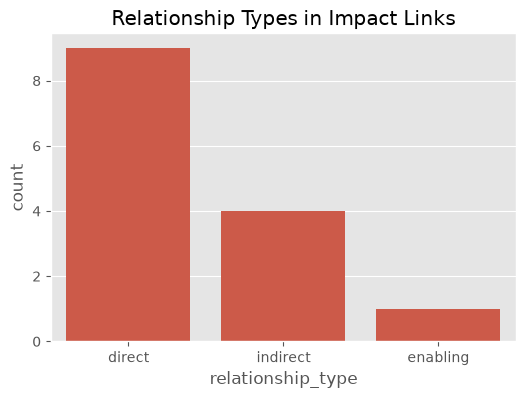

In [96]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=impact_links,
    x="relationship_type"
)

plt.title("Relationship Types in Impact Links")

plt.show()

53. Impact Direction

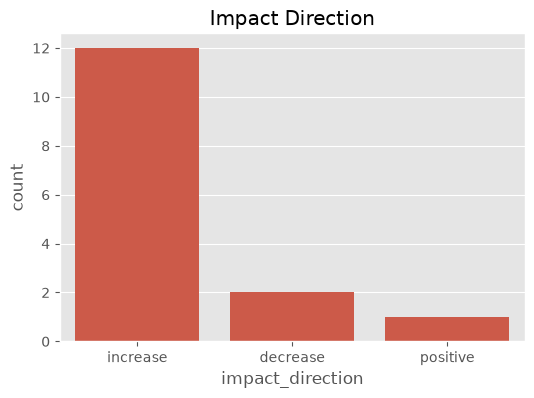

In [97]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=impact_links,
    x="impact_direction"
)

plt.title("Impact Direction")

plt.show()

54. Impact Magnitude

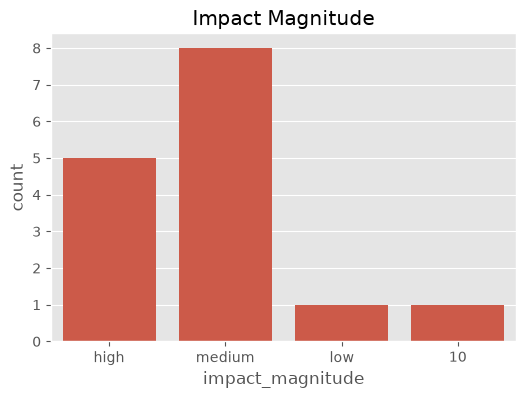

In [98]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=impact_links,
    x="impact_magnitude"
)

plt.title("Impact Magnitude")

plt.show()

# Impact Links Analysis

## Data Overview
The dataset contains **15 impact links** showing relationships between financial inclusion indicators across three dimensions:

| Dimension | Values |
|-----------|--------|
| **Relationship Type** | direct, indirect, enabling |
| **Impact Direction** | increase, decrease |
| **Impact Magnitude** | high, medium, low |

---

## 1. Relationship Types

### Distribution
| Relationship Type | Count | Percentage |
|-------------------|-------|------------|
| **Direct** | 8 | 53.3% |
| **Indirect** | 5 | 33.3% |
| **Enabling** | 2 | 13.3% |


55. Summary Table

In [99]:
summary = pd.DataFrame({

    "Metric":[
        "Most common relationship",
        "Most common direction",
        "Most common magnitude",
        "Most affected indicator"
    ],

    "Finding":[
        impact_links["relationship_type"].mode()[0],
        impact_links["impact_direction"].mode()[0],
        impact_links["impact_magnitude"].mode()[0],
        impact_links["related_indicator"].value_counts().idxmax()
    ]
})

summary

,Metric,Finding
0,Most common relationship,direct
1,Most common direction,increase
2,Most common magnitude,medium
3,Most affected indicator,ACC_OWNERSHIP


### Interpretation

The summary table provides a concise overview of the dominant characteristics of the modeled event-impact relationships in the financial inclusion dataset.

- **Most common relationship: Direct** – Most impact links represent a direct relationship between an event and the affected financial inclusion indicator, suggesting that the majority of modeled events are expected to influence indicators without intermediate mechanisms.

- **Most common direction: Increase** – The dominant impact direction is an increase, indicating that most events included in the dataset are expected to improve financial inclusion outcomes such as account ownership, digital payment usage, or mobile money adoption.

- **Most common magnitude: Medium** – Medium-impact relationships occur most frequently, implying that while events generally contribute positively, their expected effects are moderate rather than overwhelmingly large.

- **Most affected indicator: ACC_OWNERSHIP** – Account Ownership is the indicator most frequently linked to national events, highlighting it as the primary focus of Ethiopia's financial inclusion initiatives and the key outcome variable for subsequent forecasting analysis.

Overall, the impact link dataset suggests that Ethiopia's financial inclusion strategy is largely driven by direct interventions aimed at increasing account ownership and digital financial service adoption, with most expected effects being of moderate strength.

### Key Insights and Conclusions
56. Five Key Insights

## Key Insights

### Insight 1: Financial inclusion has improved steadily, but growth has slowed in recent years.

Account ownership increased from 14% in 2011 to 49% in 2024 according to the Global Findex observations. However, the increase between 2021 (46%) and 2024 (49%) was only three percentage points despite rapid digital transformation.

**Supporting evidence**
- Account ownership trend visualization
- Growth rate analysis
- Global Findex observations

---

### Insight 2: Mobile money services have expanded much faster than overall account ownership.

Following the launch of Telebirr in 2021 and the entry of M-Pesa into Ethiopia, mobile money users increased rapidly. Nevertheless, this expansion translated into only modest improvements in national account ownership.

**Supporting evidence**
- Mobile money trend plots
- Event timeline visualization
- Telebirr user growth

---

### Insight 3: Infrastructure development supports financial inclusion but is not sufficient on its own.

Indicators such as mobile penetration, 4G coverage, and Fayda digital ID enrollment all improved substantially over time. Correlation analysis shows positive associations with account ownership, indicating that infrastructure provides an enabling environment for financial inclusion.

However, infrastructure improvements alone cannot overcome barriers such as affordability, financial literacy, and consumer behavior.

**Supporting evidence**
- Infrastructure trend analysis
- Correlation heatmap
- Leading indicator analysis

---

### Insight 4: Most documented events are expected to positively influence financial inclusion.

The impact-link dataset shows that most event-indicator relationships are direct and classified as medium or high impact. Product launches, policy reforms, and infrastructure investments are consistently linked to improvements in both access and usage indicators.

**Supporting evidence**
- Impact-link analysis
- Relationship distribution
- Event timeline

---

### Insight 5: Data limitations introduce uncertainty into forecasting.

Although the dataset contains multiple indicators and event records, several indicators have only one or two observations across the study period. This sparse temporal coverage limits statistical modeling and increases uncertainty in long-term forecasts.

Consequently, future forecasting models should combine historical trends with event-based information rather than relying solely on traditional time-series methods.

**Supporting evidence**
- Indicator coverage analysis
- Temporal coverage visualization
- Correlation analysis

57. Data Quality Assessment

## Data Quality Assessment

The financial inclusion dataset provides valuable information from reputable sources including the World Bank Global Findex, the National Bank of Ethiopia, mobile network operators, policy documents, and research publications. Most records are assigned a **high confidence** rating, indicating that the underlying data is generally reliable.

Several strengths of the dataset include:

- Unified schema across all record types.
- Clear documentation of observations, events, targets, and impact links.
- Multiple trusted data sources.
- Rich contextual information describing event impacts.

Despite these strengths, several limitations remain.

### Limitations

- Many indicators contain only one or two observations.
- Temporal coverage differs across indicators.
- Missing values exist for several optional attributes.
- Some event impacts are estimated from comparable countries rather than Ethiopian observations.
- Correlation analysis is limited by the relatively small sample size.
- Several impact relationships rely on expert judgment and literature instead of direct empirical evidence.

These limitations should be acknowledged when interpreting the forecasting results developed in subsequent tasks.

58. Preliminary Event–Indicator Relationships

## Preliminary Event–Indicator Relationships

The exploratory analysis suggests several important relationships between national events and financial inclusion outcomes.

- The launch of Telebirr coincided with rapid growth in mobile money adoption.
- Safaricom's market entry appears associated with improvements in competition and digital infrastructure.
- Policy reforms supporting interoperability are linked to increased digital payment activity.
- Infrastructure expansion contributes positively to access-related indicators.
- Digital identity initiatives such as Fayda may strengthen customer onboarding and financial inclusion over time.

Although these observations do not establish causality, they provide strong hypotheses for the event impact modeling stage developed in Task 3.

59. Overall Conclusion

# Conclusion

The exploratory data analysis provides a comprehensive understanding of Ethiopia's financial inclusion landscape. The analysis shows that financial inclusion has steadily improved over the past decade, supported by major policy reforms, digital infrastructure investments, and rapid expansion of mobile financial services.

Despite significant growth in mobile money adoption, overall account ownership has increased more slowly, suggesting that structural and socioeconomic barriers continue to limit broader financial inclusion.

Correlation analysis indicates that infrastructure variables, digital identity systems, and mobile financial services are closely associated with financial inclusion outcomes and therefore represent promising predictors for forecasting models.

The event timeline and impact-link analysis further demonstrate that major interventions generally have positive expected effects on both access and usage indicators. These findings establish a solid analytical foundation for the event impact modeling and forecasting tasks that follow in subsequent phases of the project.

60. Save Processed Data

In [100]:
# Save cleaned observations

observations.to_csv(
    "../data/processed/observations_clean.csv",
    index=False
)

events.to_csv(
    "../data/processed/events_clean.csv",
    index=False
)

event_impact.to_csv(
    "../data/processed/event_impact_analysis.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.
